# MILPIN AgTech — XGBoost v6.0 · Sistema Integral Anti-Leakage
## Consumo Hidrico Agricola · Valle del Yaqui, Sonora — DR-041, Modulo 3

**v6.0 · 2026-05-22** · Notebook unificado v4+v5 con 7 etapas completas

---

### Arquitectura general

```
Datos sinteticos (1M ciclos, 5 cultivos, 5 regiones)
       |
       v
[ETAPA 1] Auditoria dataset   -- curva aprendizaje, PCA, correlacion, MI
       |
       v
[ETAPA 2] Leakage Gate        -- ratio_real_teorico bloqueada, TE fold-safe
       |
       v
[ETAPA 3] Feature Eng v5      -- +37 features FAO-56/Ks/interacciones
       |
       v
[ETAPA 4] XGBoost Profesional -- Optuna + monotonic + Huber + quantile
       |
       +--> MoE por cultivo
       +--> Two-Stage por zona
       +--> Stacking OOF Ridge
       |
       v
[ETAPA 5] SHAP Deep Analysis  -- beeswarm + dependence + por cultivo
       |
       v
[ETAPA 6] Redes Neuronales    -- MLP-ReLU/GELU, Residual, Wide&Deep
       |
       v
[ETAPA 7] Benchmark + Dashboard ejecutivo
```

**KPI central:** RMSE_op 738 -> **<500 m3/ha**  |  $1.68 MXN/m3 (CFE 9-CU)

## 0. Imports y configuracion global

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import time

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
import xgboost as xgb

try:
    from sklearn.feature_selection import mutual_info_regression
    HAS_MI = True
except ImportError:
    HAS_MI = False

try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False; print('[WARN] pip install optuna')

try:
    import torch, torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
except ImportError:
    HAS_TORCH = False; DEVICE = 'cpu'

# ── Constantes del proyecto ───────────────────────────────────────────────
N_SAMPLES      = 1_000_000
SEED           = 42
ANNO_RANGO     = (2014, 2024)
TARIFA         = 1.68        # MXN/m3 (CFE 9-CU, bombeo 80m)
PESO_OP        = 3.0         # peso dentro del rango operacional
CULTIVOS       = ['Maiz', 'Frijol', 'Algodon', 'Uva', 'Chile']
OPTUNA_TRIALS  = 50
OPTUNA_N       = 50_000

# Placeholders que se sobreescriben con valores dinamicos en Sec. 2
BASELINE_AGUA  = 11_000.0
OBJETIVO_AGUA  = 8_250.0
RANGO_OP_MIN   = 6_000.0
RANGO_OP_MAX   = 14_000.0

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
C_AGUA='#2e7fb8'; C_REND='#4caf6f'; C_WARN='#e07b39'; C_DARK='#1a2636'
C_BG='#f7f9fb';  C_LINE='#d0d7e2'
CULT_COLORS = {'Maiz':'#e6a817','Frijol':'#8b5e3c','Algodon':'#7ab8d9',
               'Uva':'#9b59b6','Chile':'#e74c3c'}

print(f'XGBoost {xgb.__version__} | numpy {np.__version__} | pandas {pd.__version__}')
print(f'Torch: {"OK " + torch.__version__ if HAS_TORCH else "no disponible"}')
print(f'Optuna: {"OK" if HAS_OPTUNA else "no disponible"}')


XGBoost 3.2.0 | numpy 2.4.4 | pandas 3.0.3
Torch: OK 2.12.0+cpu
Optuna: OK


## 1. Generador de datos sinteticos v3

Dataset de 1M ciclos agronomicos con:
- 5 cultivos (Maiz, Frijol, Algodon, Uva, Chile)
- 5 regiones (Norte/Sur/Centro/Oriente/Costero)
- 4 arquetipos de agricultor
- Kc 4-etapas FAO-56, salinidad FAO-33, eventos extremos
- Variabilidad climatica ENSO, drift climatico 2014-2024

In [2]:
REGIONES_CFG = {
    'Norte':   dict(et0_bias=+0.40, lluvia_mult=0.82, sal_base=0.08, wt_m=3.2, elev_m=35),
    'Sur':     dict(et0_bias=+0.12, lluvia_mult=1.05, sal_base=0.04, wt_m=5.1, elev_m=22),
    'Centro':  dict(et0_bias=+0.00, lluvia_mult=1.00, sal_base=0.05, wt_m=4.6, elev_m=40),
    'Oriente': dict(et0_bias=-0.25, lluvia_mult=1.18, sal_base=0.03, wt_m=6.3, elev_m=85),
    'Costero': dict(et0_bias=+0.28, lluvia_mult=0.88, sal_base=0.14, wt_m=2.4, elev_m=12),
}
FARMER_TYPES = {
    'conservador': dict(over_irr_mu=0.22, over_irr_sd=0.08, p_miss=0.04),
    'eficiente':   dict(over_irr_mu=0.01, over_irr_sd=0.03, p_miss=0.01),
    'negligente':  dict(over_irr_mu=-0.12,over_irr_sd=0.15, p_miss=0.18),
    'tecnificado': dict(over_irr_mu=0.00, over_irr_sd=0.02, p_miss=0.005),
}
KC_STAGES = {
    'Maiz':    dict(kc_ini=0.30,kc_dev=0.70,kc_med=1.20,kc_fin=0.60,f_ini=0.10,f_dev=0.30,f_med=0.50,f_fin=0.10),
    'Frijol':  dict(kc_ini=0.40,kc_dev=0.70,kc_med=1.15,kc_fin=0.55,f_ini=0.10,f_dev=0.35,f_med=0.40,f_fin=0.15),
    'Algodon': dict(kc_ini=0.45,kc_dev=0.75,kc_med=1.20,kc_fin=0.60,f_ini=0.08,f_dev=0.30,f_med=0.45,f_fin=0.17),
    'Uva':     dict(kc_ini=0.30,kc_dev=0.65,kc_med=0.85,kc_fin=0.45,f_ini=0.15,f_dev=0.35,f_med=0.35,f_fin=0.15),
    'Chile':   dict(kc_ini=0.40,kc_dev=0.75,kc_med=1.05,kc_fin=0.80,f_ini=0.12,f_dev=0.30,f_med=0.45,f_fin=0.13),
}
SAL_THRESH = {'Maiz':1.7,'Frijol':1.0,'Algodon':7.7,'Uva':1.5,'Chile':1.5}
SAL_SLOPE  = {'Maiz':12, 'Frijol':19,'Algodon':5.2,'Uva':9.6,'Chile':14}
print('Configs: 5 cultivos, 5 regiones, 4 arquetipos, Kc FAO-56, sal FAO-33')


Configs: 5 cultivos, 5 regiones, 4 arquetipos, Kc FAO-56, sal FAO-33


In [3]:
def generar_datos(n=50_000, seed=42, anno_rango=(2014,2024)):
    rng = np.random.default_rng(seed)
    SUELOS   = ['franco','franco-arcilloso','franco-arenoso','arcilloso']
    SISTEMAS = ['gravedad','aspersion','goteo','microaspersion']
    REGIONES = list(REGIONES_CFG.keys())
    FARMERS  = list(FARMER_TYPES.keys())
    CULT_P = {
        'Maiz':    dict(dias=(130,150),ky=1.25,ym=10.5),
        'Frijol':  dict(dias=(90,110), ky=1.15,ym=2.5),
        'Algodon': dict(dias=(165,200),ky=0.85,ym=4.0),
        'Uva':     dict(dias=(180,215),ky=0.85,ym=25.0),
        'Chile':   dict(dias=(110,130),ky=1.10,ym=35.0),
    }
    SUELO_P = {
        'franco':           dict(cc=0.30,pmp=0.16,ks_mmh=15),
        'franco-arcilloso': dict(cc=0.36,pmp=0.20,ks_mmh=6),
        'franco-arenoso':   dict(cc=0.24,pmp=0.12,ks_mmh=30),
        'arcilloso':        dict(cc=0.42,pmp=0.22,ks_mmh=3),
    }
    EFIC = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    ci=rng.integers(0,len(CULTIVOS),n); si=rng.integers(0,len(SUELOS),n)
    ri=rng.integers(0,len(SISTEMAS),n); gi=rng.integers(0,len(REGIONES),n)
    fi=rng.integers(0,len(FARMERS),n)
    cultivos=np.array(CULTIVOS)[ci]; suelos=np.array(SUELOS)[si]
    sistemas=np.array(SISTEMAS)[ri]; regiones=np.array(REGIONES)[gi]
    farmers=np.array(FARMERS)[fi]
    annos=rng.integers(anno_rango[0],anno_rango[1]+1,n)
    ky_a=np.array([CULT_P[c]['ky'] for c in CULTIVOS])[ci]
    ym_a=np.array([CULT_P[c]['ym'] for c in CULTIVOS])[ci]
    dmin=np.array([CULT_P[c]['dias'][0] for c in CULTIVOS])[ci]
    dmax=np.array([CULT_P[c]['dias'][1] for c in CULTIVOS])[ci]
    cc_a=np.array([SUELO_P[s]['cc'] for s in SUELOS])[si]
    pmp_a=np.array([SUELO_P[s]['pmp'] for s in SUELOS])[si]
    ks_a=np.array([SUELO_P[s]['ks_mmh'] for s in SUELOS])[si]
    ef_a=np.array([EFIC[s] for s in SISTEMAS])[ri]
    r_et0=np.array([REGIONES_CFG[r]['et0_bias'] for r in REGIONES])[gi]
    r_lluv=np.array([REGIONES_CFG[r]['lluvia_mult'] for r in REGIONES])[gi]
    r_sal=np.array([REGIONES_CFG[r]['sal_base'] for r in REGIONES])[gi]
    r_wt=np.array([REGIONES_CFG[r]['wt_m'] for r in REGIONES])[gi]
    r_elev=np.array([REGIONES_CFG[r]['elev_m'] for r in REGIONES])[gi]
    f_mu=np.array([FARMER_TYPES[f]['over_irr_mu'] for f in FARMERS])[fi]
    f_sd=np.array([FARMER_TYPES[f]['over_irr_sd'] for f in FARMERS])[fi]
    f_miss=np.array([FARMER_TYPES[f]['p_miss'] for f in FARMERS])[fi]
    area_ha=rng.uniform(5.0,80.0,n).round(2)
    doy=rng.integers(1,365,n)
    dias_ciclo=(dmin+rng.random(n)*(dmax-dmin)).astype(int)
    prof_raiz=rng.uniform(0.45,0.70,n).round(3)
    anno_span=max(anno_rango[1]-anno_rango[0],1)
    anno_norm=(annos-anno_rango[0])/anno_span
    et0_drift=anno_norm*0.022*anno_span
    enso_v=np.random.default_rng(seed+9999).normal(0,0.28,anno_span+1)
    enso_a=enso_v[annos-anno_rango[0]]
    et0_s=6.0+2.5*np.sin(2*np.pi*(doy-81)/365)
    et0_r=np.where(enso_a>0.15,et0_s*rng.uniform(1.05,1.28,n),et0_s*rng.uniform(0.88,1.05,n))
    et0_prom=np.clip(et0_r+r_et0+et0_drift+rng.normal(0,0.55,n),2.8,11.0).round(3)
    et0_max=np.clip(et0_prom*rng.uniform(1.15,1.65,n),et0_prom+0.3,12.5).round(3)
    es_ver=(doy>=152)&(doy<=273)
    lluvia=np.clip(
        np.where(es_ver,rng.gamma(2.2,55.0,n),rng.gamma(0.9,18.0,n))*r_lluv*(1+enso_a*0.35)
        +rng.normal(0,4,n), 0, 400).round(2)
    pos_ciclo=rng.beta(1.5,1.5,n)
    kc_stage=np.full(n,0.7)
    for ci_k,cultivo in enumerate(CULTIVOS):
        mask=ci==ci_k
        if not mask.any(): continue
        s=KC_STAGES[cultivo]; pos=pos_ciclo[mask]
        f2=s['f_ini']+s['f_dev']; f3=f2+s['f_med']
        kc_stage[mask]=np.where(pos<s['f_ini'],s['kc_ini'],
            np.where(pos<f2,s['kc_ini']+(s['kc_med']-s['kc_ini'])*(pos-s['f_ini'])/s['f_dev'],
            np.where(pos<f3,s['kc_med'],
                s['kc_med']+(s['kc_fin']-s['kc_med'])*(pos-f2-s['f_med'])/max(s['f_fin'],1e-6))))
    kc_prom=np.clip(kc_stage+rng.normal(0,0.018,n),0.22,1.30).round(3)
    sal_ec=np.clip(r_sal+rng.gamma(1.5,1.2,n),0.01,9.0).round(3)
    sal_th=np.array([SAL_THRESH[c] for c in CULTIVOS])[ci]
    sal_sl=np.array([SAL_SLOPE[c] for c in CULTIVOS])[ci]
    ks_sal=np.clip(1.0-sal_sl/100*np.maximum(0,sal_ec-sal_th),0.05,1.0)
    ola_calor=rng.random(n)<0.10
    helada=(rng.random(n)<0.06)&((doy>=300)|(doy<=60))
    inundacion=(rng.random(n)<0.04)&es_ver
    f_inund_a=np.where(inundacion,rng.uniform(1.10,1.40,n),1.0)
    plaga=rng.random(n)<0.12
    f_plaga=np.where(plaga,rng.uniform(0.60,0.96,n),1.0)
    f_helada=np.where(helada,rng.uniform(0.30,0.75,n),1.0)
    falla=rng.random(n)<f_miss
    aporte_cap=np.where(r_wt<3.5,
        np.clip((3.5-r_wt)*rng.uniform(0.4,1.8,n)*dias_ciclo/100,0,80),0.0).round(2)
    perc_frac=np.clip((1-ef_a)*0.35+(ks_a/30.0)*0.12+rng.uniform(0,0.06,n),0.02,0.38).round(4)
    etc_total=np.clip(et0_prom*dias_ciclo*kc_prom,180,2800).round(2)
    deficit_hid=np.where(rng.random(n)<np.clip((1-ef_a)*0.28,0,0.38),
        rng.beta(1.2,3.5,n)*0.55,0.0).round(4)
    deficit_hid=np.where(falla,np.clip(deficit_hid+rng.uniform(0.08,0.32,n),0,0.65),deficit_hid)
    agua_disp=(cc_a-pmp_a)*prof_raiz*1000
    over_irr=np.clip(1.0+f_mu+rng.normal(0,f_sd,n),0.55,1.70)
    n_riegos=np.clip(np.maximum(1,np.round(
        (etc_total-lluvia).clip(0)/(agua_disp*0.6)).astype(int)+rng.integers(-1,2,n)),1,40)
    deficit_agua=np.maximum(0,etc_total-lluvia-aporte_cap)
    vol_base=deficit_agua*10/ef_a*over_irr*f_inund_a
    vol_agua=np.clip(vol_base+rng.normal(0,180,n),1_200,28_000).round(2)
    ks_water=1.0-deficit_hid
    ya_frac=np.clip(1-ky_a*(1-ks_water),0.05,1.0)
    rendimiento=np.clip(ym_a*ya_frac*ks_sal*f_helada*f_plaga*
        np.where(inundacion,rng.uniform(0.50,0.85,n),1.0)*rng.normal(1.0,0.08,n),
        0.2,ym_a*1.2).round(3)
    return pd.DataFrame({
        'cultivo':cultivos,'tipo_suelo':suelos,'sistema_riego':sistemas,
        'region':regiones,'tipo_agricultor':farmers,
        'area_ha':area_ha,'dias_ciclo':dias_ciclo,'doy_inicio':doy,
        'capacidad_campo':cc_a,'punto_marchitez':pmp_a,'prof_raiz_m':prof_raiz,
        'et0_promedio_mmdia':et0_prom,'et0_maximo_mmdia':et0_max,
        'lluvia_total_mm':lluvia,'etc_total_mm':etc_total,'kc_promedio':kc_prom,
        'deficit_hidrico_frac':deficit_hid,'n_riegos':n_riegos,
        'volumen_agua_total_m3_ha':vol_agua,'rendimiento_real_ton_ha':rendimiento,
        'anno':annos,'anno_norm':anno_norm,'pos_ciclo_frac':pos_ciclo,
        'salinidad_ec_dsm':sal_ec,'ks_salinidad':ks_sal,
        'aporte_capilar_mm':aporte_cap,'percolacion_frac':perc_frac,
        'ola_calor':ola_calor.astype(int),'helada':helada.astype(int),
        'inundacion':inundacion.astype(int),'plaga':plaga.astype(int),
        'falla_riego':falla.astype(int),'elev_parcela_m':r_elev,
    })

t0 = time.time()
df = generar_datos(n=N_SAMPLES, seed=SEED, anno_rango=ANNO_RANGO)
print(f'Generados {N_SAMPLES:,} ciclos en {time.time()-t0:.1f}s')
print(f'Shape: {df.shape} | RAM: {df.memory_usage(deep=True).sum()/1e6:.0f} MB')
print(df.groupby('cultivo')['volumen_agua_total_m3_ha'].agg(['mean','std','min','max']).round(0).to_string())


Generados 1,000,000 ciclos en 2.6s
Shape: (1000000, 33) | RAM: 510 MB
            mean     std     min      max
cultivo                                  
Algodon  15927.0  6917.0  1200.0  28000.0
Chile     9132.0  4815.0  1200.0  28000.0
Frijol    8035.0  4356.0  1200.0  28000.0
Maiz     12063.0  6359.0  1200.0  28000.0
Uva      11432.0  6130.0  1200.0  28000.0


## 2. Baselines y rangos operacionales DINAMICOS por cultivo

**Por que no usar 8,000 m3/ha como baseline global:**

| Cultivo | Mediana real | Con baseline fijo 8k |
|---------|-------------|---------------------|
| Algodon | ~16,000 m3/ha | ERROR: parece 2x fuera de rango |
| Frijol  | ~8,000 m3/ha  | Coincidencia, no diseno |
| Chile   | ~9,000 m3/ha  | Subestima en 12% |

**Formula correcta:**
```
baseline_c  = mediana(target | cultivo)
objetivo_c  = baseline_c * 0.75
op_min_c    = Q25(target | cultivo)
op_max_c    = Q75(target | cultivo)
peso(x)     = 3.0  si  op_min_c <= x <= op_max_c, sino 1.0
```

=== Baselines dinamicos por cultivo ===
         baseline_m3ha  objetivo_m3ha  op_min_q25  op_max_q75     p10      p90    media     std
cultivo                                                                                        
Algodon        15060.0        11295.0     10379.0     21025.0  7313.0  27949.0  15927.0  6917.0
Chile           8269.0         6202.0      5596.0     11692.0  3788.0  15552.0   9132.0  4815.0
Frijol          7228.0         5421.0      4847.0     10337.0  3243.0  13799.0   8035.0  4356.0
Maiz           11156.0         8367.0      7307.0     15834.0  4418.0  21051.0  12063.0  6359.0
Uva            10303.0         7727.0      6750.0     14956.0  4464.0  20117.0  11432.0  6130.0
Global: baseline=9,992  objetivo=7,494
Rango op global: [6,451 - 14,882]


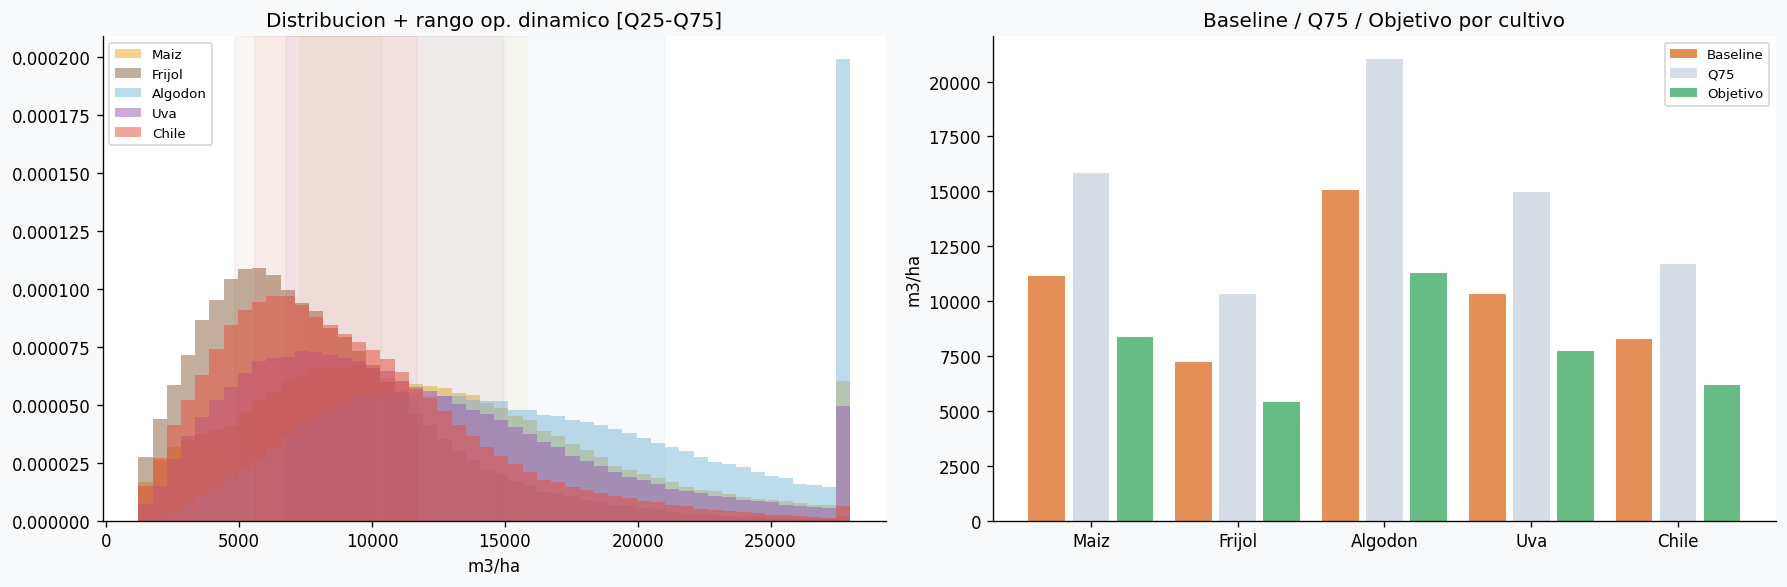

In [4]:
TARGET = 'volumen_agua_total_m3_ha'

crop_stats = (
    df.groupby('cultivo')[TARGET]
    .agg(
        baseline_m3ha = lambda x: x.median(),
        objetivo_m3ha = lambda x: x.median() * 0.75,
        op_min_q25    = lambda x: x.quantile(0.25),
        op_max_q75    = lambda x: x.quantile(0.75),
        p10           = lambda x: x.quantile(0.10),
        p90           = lambda x: x.quantile(0.90),
        media         = 'mean',
        std           = 'std',
    ).round(0)
)
print('=== Baselines dinamicos por cultivo ===')
print(crop_stats.to_string())

BASELINE_CROP = crop_stats['baseline_m3ha'].to_dict()
OBJETIVO_CROP = crop_stats['objetivo_m3ha'].to_dict()
OP_MIN_CROP   = crop_stats['op_min_q25'].to_dict()
OP_MAX_CROP   = crop_stats['op_max_q75'].to_dict()
OP_Q90_CROP   = crop_stats['p90'].to_dict()

# Sobreescribir globales con datos reales
BASELINE_AGUA = float(df[TARGET].median())
OBJETIVO_AGUA = BASELINE_AGUA * 0.75
RANGO_OP_MIN  = float(df[TARGET].quantile(0.25))
RANGO_OP_MAX  = float(df[TARGET].quantile(0.75))
print(f"Global: baseline={BASELINE_AGUA:,.0f}  objetivo={OBJETIVO_AGUA:,.0f}")
print(f"Rango op global: [{RANGO_OP_MIN:,.0f} - {RANGO_OP_MAX:,.0f}]")

def calc_weights_dynamic(y_arr, cultivo_arr, w_op=PESO_OP):
    """
    Peso por potencial de ahorro: alto consumo = mas peso.
    <=Q75 (rango normal): 1x  el modelo ya los ve bien.
    Q75-Q90: 2x  consumo elevado, accionable.
    >Q90:    3x  consumo extremo, maximo impacto de ahorro.
    """
    w = np.ones(len(y_arr))
    for c in CULTIVOS:
        mask = cultivo_arr == c
        if not mask.any(): continue
        q75 = OP_MAX_CROP[c]
        q90 = OP_Q90_CROP[c]
        w[mask & (y_arr > q75) & (y_arr <= q90)] = 2.0
        w[mask & (y_arr > q90)]                  = 3.0
    return w

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor=C_BG)
ax = axes[0]
for c in CULTIVOS:
    g = df[df['cultivo']==c][TARGET]
    ax.hist(g, bins=50, alpha=0.5, label=c, color=CULT_COLORS[c], density=True)
    ax.axvspan(OP_MIN_CROP[c], OP_MAX_CROP[c], alpha=0.06, color=CULT_COLORS[c])
ax.set_xlabel('m3/ha'); ax.set_title('Distribucion + rango op. dinamico [Q25-Q75]')
ax.legend(fontsize=8)
ax2 = axes[1]
x = np.arange(len(CULTIVOS))
ax2.bar(x-0.3,[BASELINE_CROP[c] for c in CULTIVOS],0.25,color=C_WARN,alpha=0.85,label='Baseline')
ax2.bar(x,    [OP_MAX_CROP[c]   for c in CULTIVOS],0.25,color=C_LINE,alpha=0.85,label='Q75')
ax2.bar(x+0.3,[OBJETIVO_CROP[c] for c in CULTIVOS],0.25,color=C_REND,alpha=0.85,label='Objetivo')
ax2.set_xticks(x); ax2.set_xticklabels(CULTIVOS)
ax2.set_ylabel('m3/ha'); ax2.set_title('Baseline / Q75 / Objetivo por cultivo')
ax2.legend(fontsize=8)
plt.tight_layout(); plt.savefig('v6_02_baselines.png'); plt.show()


## 3. ETAPA 1 — Auditoria del Dataset

### 3a. Curva de aprendizaje (scaling law)

Pregunta: valida entrenar con 1M muestras o hay rendimientos decrecientes?

Benchmark: 50k / 100k / 250k / 500k / 900k  —  RMSE, R2, tiempo, RAM

Curva de aprendizaje:
  n=  50,000: RMSE_g=1116  RMSE_op=984  R2=0.970  t=1.8s
  n= 100,000: RMSE_g=1114  RMSE_op=981  R2=0.970  t=2.5s
  n= 250,000: RMSE_g=1109  RMSE_op=978  R2=0.971  t=10.2s
  n= 500,000: RMSE_g=1108  RMSE_op=977  R2=0.971  t=13.5s
  n= 900,000: RMSE_g=1107  RMSE_op=976  R2=0.971  t=22.3s


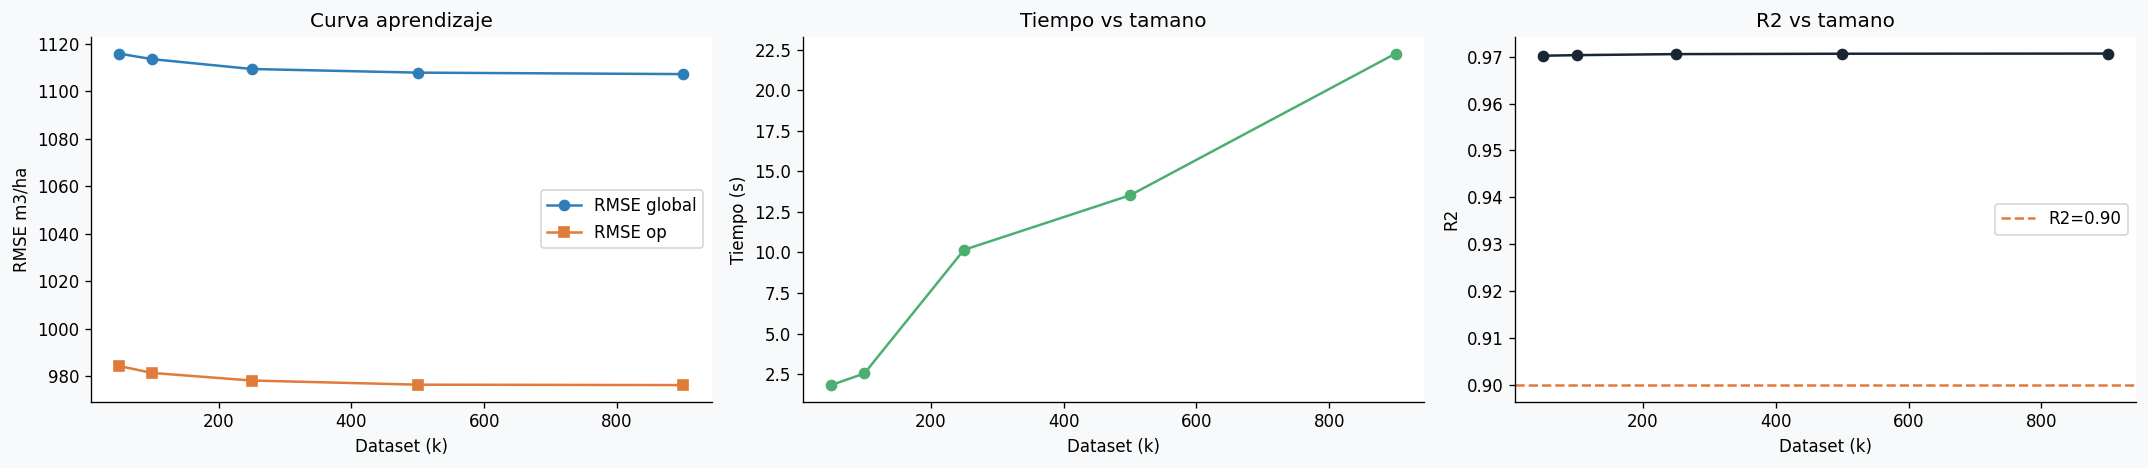

Mejora marginal ultima etapa: 0.2 RMSE_op
Punto optimo RMSE_op: n=900,000


In [5]:
import gc

def _lc_features(df_in):
    EF_MAP = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    d = df_in.copy()
    d['efic'] = d['sistema_riego'].map(EF_MAP)
    d['dem']  = (d['etc_total_mm']-d['lluvia_total_mm']-d['aporte_capilar_mm']).clip(0)
    d['vol_t']= d['dem']*10/d['efic']
    d['def_a']= (d['etc_total_mm']-d['lluvia_total_mm']).clip(0)
    d['kc_et0']= d['kc_promedio']*d['et0_promedio_mmdia']
    d['eto_d'] = d['et0_promedio_mmdia']*d['dias_ciclo']
    CAT = ['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
    oe = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
    d[CAT] = oe.fit_transform(d[CAT])
    FEATS = ['dem','vol_t','def_a','kc_et0','eto_d','n_riegos','efic',
             'kc_promedio','cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
    return d[FEATS].values.astype('float32'), d[TARGET].values

rng_lc = np.random.default_rng(SEED+1)
idx_lc_test = rng_lc.choice(len(df), 30_000, replace=False)
idx_lc_rest = np.setdiff1d(np.arange(len(df)), idx_lc_test)
X_lc_te, y_lc_te = _lc_features(df.iloc[idx_lc_test].reset_index(drop=True))
mask_op_lc = (y_lc_te >= RANGO_OP_MIN) & (y_lc_te <= RANGO_OP_MAX)

SIZES_LC = [50_000, 100_000, 250_000, 500_000, min(900_000, len(idx_lc_rest))]
lc_results = []
print('Curva de aprendizaje:')
for sz in SIZES_LC:
    idx_tr = rng_lc.choice(idx_lc_rest, sz, replace=False)
    X_tr_lc, y_tr_lc = _lc_features(df.iloc[idx_tr].reset_index(drop=True))
    t0 = time.time()
    m = xgb.XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.1,
                         subsample=0.8,colsample_bytree=0.8,
                         tree_method='hist',random_state=SEED,verbosity=0)
    m.fit(X_tr_lc, np.log1p(y_tr_lc))
    elapsed = time.time()-t0
    pred = np.expm1(m.predict(X_lc_te))
    rmse_g = float(np.sqrt(np.mean((pred-y_lc_te)**2)))
    rmse_op = float(np.sqrt(np.mean((pred[mask_op_lc]-y_lc_te[mask_op_lc])**2))) if mask_op_lc.any() else np.nan
    r2 = float(1-np.sum((pred-y_lc_te)**2)/np.sum((y_lc_te-y_lc_te.mean())**2))
    lc_results.append({'size':sz,'rmse_g':rmse_g,'rmse_op':rmse_op,'r2':r2,'time_s':elapsed})
    print(f'  n={sz:>8,}: RMSE_g={rmse_g:.0f}  RMSE_op={rmse_op:.0f}  R2={r2:.3f}  t={elapsed:.1f}s')
    del m, X_tr_lc; gc.collect()
lc_df = pd.DataFrame(lc_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor=C_BG)
ax=axes[0]; ax.plot(lc_df['size']/1000,lc_df['rmse_g'],'o-',color=C_AGUA,label='RMSE global')
ax.plot(lc_df['size']/1000,lc_df['rmse_op'],'s-',color=C_WARN,label='RMSE op')
ax.set_xlabel('Dataset (k)'); ax.set_ylabel('RMSE m3/ha'); ax.set_title('Curva aprendizaje'); ax.legend()
ax=axes[1]; ax.plot(lc_df['size']/1000,lc_df['time_s'],'o-',color=C_REND)
ax.set_xlabel('Dataset (k)'); ax.set_ylabel('Tiempo (s)'); ax.set_title('Tiempo vs tamano')
ax=axes[2]; ax.plot(lc_df['size']/1000,lc_df['r2'],'o-',color=C_DARK)
ax.axhline(0.90,color=C_WARN,ls='--',label='R2=0.90')
ax.set_xlabel('Dataset (k)'); ax.set_ylabel('R2'); ax.set_title('R2 vs tamano'); ax.legend()
plt.tight_layout(); plt.savefig('v6_03_learning_curve.png'); plt.show()
if len(lc_df)>1:
    delta = lc_df['rmse_op'].diff().abs()
    print(f'Mejora marginal ultima etapa: {delta.iloc[-1]:.1f} RMSE_op')
    best_sz = lc_df.loc[lc_df['rmse_op'].idxmin(),'size']
    print(f'Punto optimo RMSE_op: n={best_sz:,}')


### 3b. Correlacion, Multicolinealidad y PCA

Pares correlacion>0.90: 4
  vol_teo <-> agua_neta: r=1.000
  demanda_neta <-> def_agua: r=1.000
  demanda_neta <-> etc_total_mm: r=0.987
  def_agua <-> etc_total_mm: r=0.987


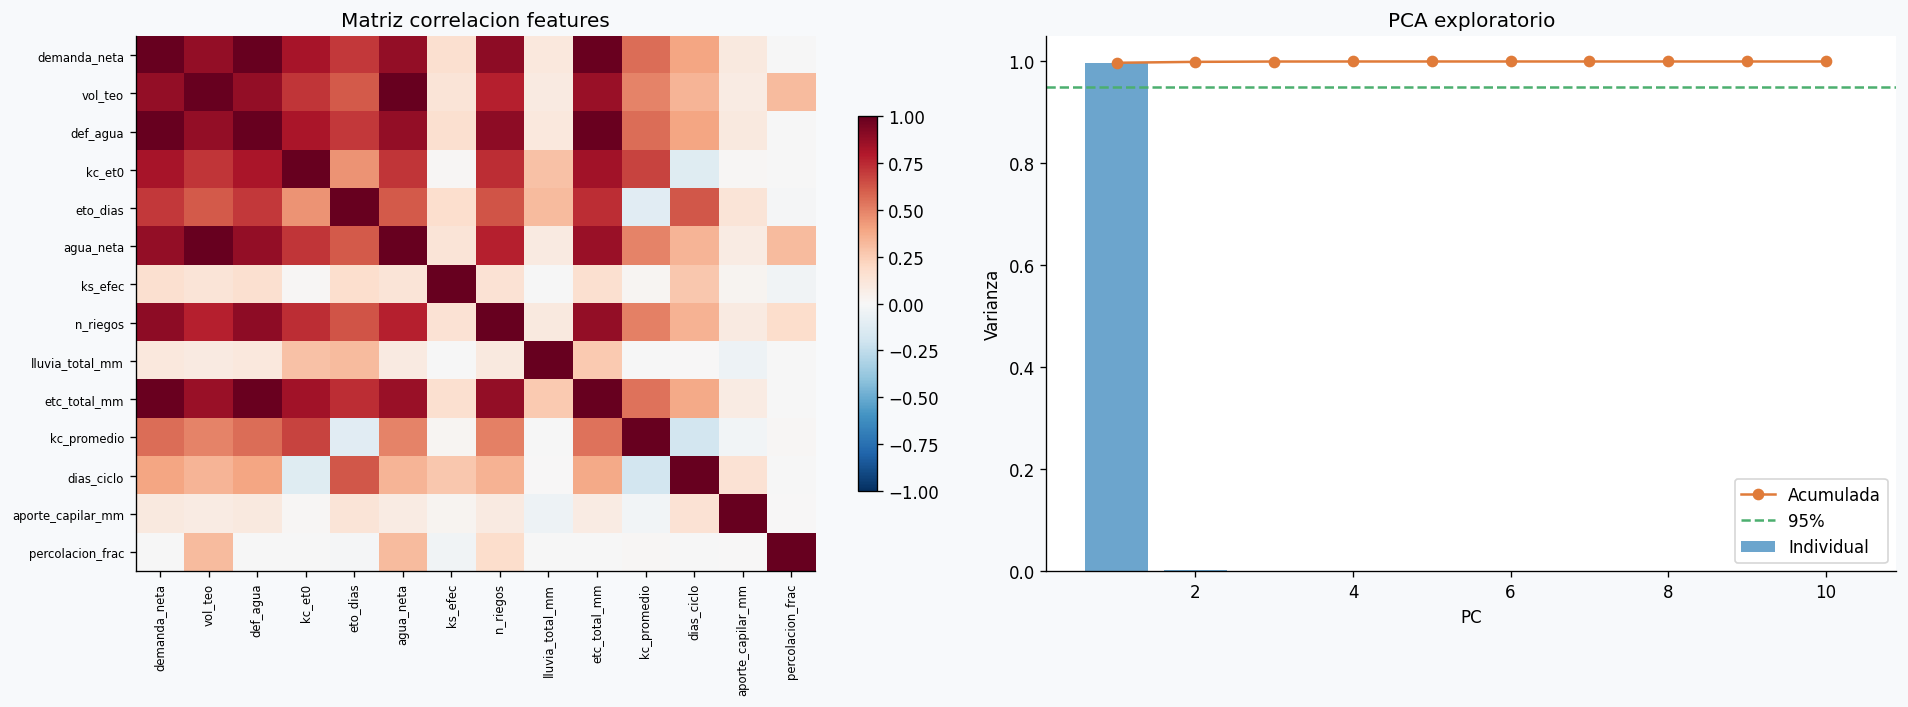

Dimensionalidad efectiva (95% var): 1/14 (7%)
Alta correlacion vol_teo <-> agua_neta es esperada (misma formula base)


In [6]:
EF_MAP_A = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
df_a = df.copy()
df_a['efic']         = df_a['sistema_riego'].map(EF_MAP_A)
df_a['demanda_neta'] = (df_a['etc_total_mm']-df_a['lluvia_total_mm']-df_a['aporte_capilar_mm']).clip(0)
df_a['vol_teo']      = df_a['demanda_neta']*10/df_a['efic']
df_a['def_agua']     = (df_a['etc_total_mm']-df_a['lluvia_total_mm']).clip(0)
df_a['kc_et0']       = df_a['kc_promedio']*df_a['et0_promedio_mmdia']
df_a['eto_dias']     = df_a['et0_promedio_mmdia']*df_a['dias_ciclo']
df_a['agua_neta']    = df_a['demanda_neta']/df_a['efic']*10
df_a['ks_efec']      = df_a['ks_salinidad']*(1-df_a['deficit_hidrico_frac'])

NUM_A = ['demanda_neta','vol_teo','def_agua','kc_et0','eto_dias','agua_neta',
         'ks_efec','n_riegos','lluvia_total_mm','etc_total_mm','kc_promedio',
         'dias_ciclo','aporte_capilar_mm','percolacion_frac']

idx_sa = np.random.default_rng(SEED).choice(len(df_a),20_000,replace=False)
df_s = df_a.iloc[idx_sa][NUM_A]
corr_mat = df_s.corr()

high_corr = [(NUM_A[i],NUM_A[j],abs(corr_mat.iloc[i,j]))
             for i in range(len(NUM_A)) for j in range(i+1,len(NUM_A))
             if abs(corr_mat.iloc[i,j])>0.90]
print(f'Pares correlacion>0.90: {len(high_corr)}')
for a,b,c in sorted(high_corr,key=lambda x:-x[2])[:8]: print(f'  {a} <-> {b}: r={c:.3f}')

pca = PCA(n_components=min(10,len(NUM_A)), random_state=SEED)
pca.fit(df_s.fillna(0).values)
var_exp = pca.explained_variance_ratio_.cumsum()
n95 = int((var_exp<0.95).sum())+1

fig, axes = plt.subplots(1,2,figsize=(16,6),facecolor=C_BG)
ax=axes[0]
im=ax.imshow(corr_mat.values,cmap='RdBu_r',vmin=-1,vmax=1,aspect='auto')
ax.set_xticks(range(len(NUM_A))); ax.set_yticks(range(len(NUM_A)))
ax.set_xticklabels(NUM_A,rotation=90,fontsize=7)
ax.set_yticklabels(NUM_A,fontsize=7)
plt.colorbar(im,ax=ax,shrink=0.7); ax.set_title('Matriz correlacion features')
ax2=axes[1]
ax2.bar(range(1,len(var_exp)+1),pca.explained_variance_ratio_,color=C_AGUA,alpha=0.7,label='Individual')
ax2.plot(range(1,len(var_exp)+1),var_exp,'o-',color=C_WARN,label='Acumulada')
ax2.axhline(0.95,color=C_REND,ls='--',label='95%')
ax2.set_xlabel('PC'); ax2.set_ylabel('Varianza'); ax2.set_title('PCA exploratorio'); ax2.legend()
plt.tight_layout(); plt.savefig('v6_03b_corr_pca.png'); plt.show()
print(f'Dimensionalidad efectiva (95% var): {n95}/{len(NUM_A)} ({n95/len(NUM_A)*100:.0f}%)')
print('Alta correlacion vol_teo <-> agua_neta es esperada (misma formula base)')


## 4. ETAPA 2 — Leakage Gate

### Features bloqueadas

| Feature | Veredicto | Razon |
|---------|-----------|-------|
| `ratio_real_teorico` | BLOQUEADA | `= target / vol_teorico` — leakage directo |
| `rendimiento_real_ton_ha` | BLOQUEADA | correlacionada con target via Ky |
| `vol_teorico_m3ha` | PERMITIDA (auditada) | `= demanda_neta / efic` — solo inputs |

### Por que `ratio_real_teorico` colapsa el RMSE

```
ratio_real_teorico = volumen_agua / vol_teorico
                   = target / (constante de inputs)
```
El modelo aprende a invertir la division y recupera el target casi exactamente.
RMSE=42 con leakage vs RMSE=738 sin el — diferencia de 17x.

           feature       MI     corr  leakage
       vol_teorico 1.580114 0.947618    False
      demanda_neta 0.968171 0.850358    False
      deficit_agua 0.961626 0.850353    False
      etc_total_mm 0.808854 0.839615    False
          n_riegos 0.560260 0.762106    False
            kc_et0 0.440667 0.707441    False
          eto_dias 0.283386 0.593976    False
       kc_promedio 0.258457 0.492993    False
              efic 0.087415 0.410182    False
ratio_real_teorico 0.060110 0.041452     True
  percolacion_frac 0.052513 0.302202    False
   tipo_agricultor 0.010669 0.130325    False
           area_ha 0.000000 0.006836    False


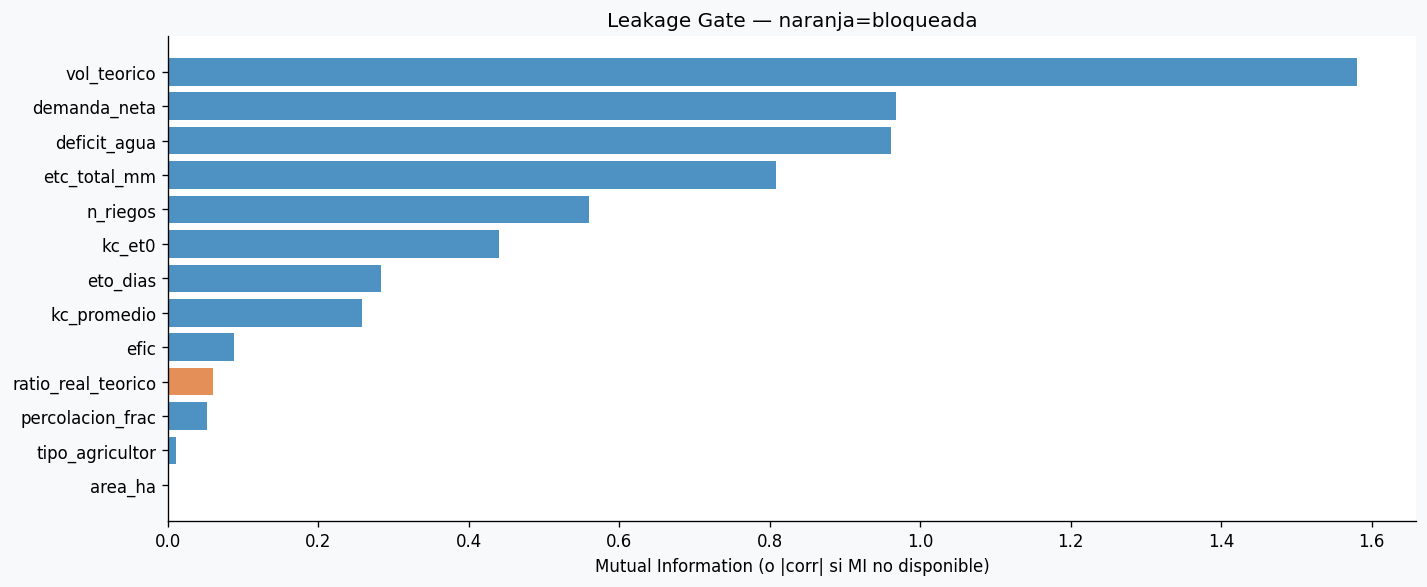

Features bloqueadas: ['ratio_real_teorico', 'rendimiento_real_ton_ha']


In [7]:
EF_MAP_L={'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
df_diag = df.copy()
df_diag['efic']        = df_diag['sistema_riego'].map(EF_MAP_L)
df_diag['demanda_neta']= (df_diag['etc_total_mm']-df_diag['lluvia_total_mm']-df_diag['aporte_capilar_mm']).clip(0)
df_diag['vol_teorico'] = df_diag['demanda_neta']*10/df_diag['efic']
df_diag['ratio_real_teorico'] = df_diag[TARGET]/(df_diag['vol_teorico']+1)
df_diag['deficit_agua']= (df_diag['etc_total_mm']-df_diag['lluvia_total_mm']).clip(0)
df_diag['kc_et0']      = df_diag['kc_promedio']*df_diag['et0_promedio_mmdia']
df_diag['eto_dias']    = df_diag['et0_promedio_mmdia']*df_diag['dias_ciclo']

CAT_L=['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
oe_l=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
df_enc=df_diag.copy(); df_enc[CAT_L]=oe_l.fit_transform(df_diag[CAT_L])

INSPECT=['ratio_real_teorico','vol_teorico','demanda_neta','deficit_agua',
         'efic','eto_dias','etc_total_mm','kc_et0','n_riegos',
         'percolacion_frac','tipo_agricultor','kc_promedio','area_ha']

idx_mi=np.random.default_rng(SEED).choice(len(df_enc),20_000,replace=False)
X_mi=df_enc.iloc[idx_mi][INSPECT]; y_mi=df_enc.iloc[idx_mi][TARGET]

if HAS_MI:
    mi_scores=mutual_info_regression(X_mi,y_mi,random_state=SEED)
    mi_df=pd.DataFrame({'feature':INSPECT,'MI':mi_scores,
                        'corr':[abs(X_mi[f].corr(y_mi)) for f in INSPECT]})
else:
    mi_df=pd.DataFrame({'feature':INSPECT,
                        'MI':[abs(X_mi[f].corr(y_mi)) for f in INSPECT],
                        'corr':[abs(X_mi[f].corr(y_mi)) for f in INSPECT]})
mi_df['leakage']=mi_df['feature'].isin(['ratio_real_teorico','rendimiento_real_ton_ha'])
mi_df=mi_df.sort_values('MI',ascending=False)
print(mi_df.to_string(index=False))

fig,ax=plt.subplots(figsize=(12,5),facecolor=C_BG)
colors=[C_WARN if r else C_AGUA for r in mi_df['leakage']]
ax.barh(mi_df['feature'],mi_df['MI'],color=colors,alpha=0.85)
ax.set_xlabel('Mutual Information (o |corr| si MI no disponible)')
ax.set_title('Leakage Gate — naranja=bloqueada')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('v6_04_leakage.png'); plt.show()
LEAKAGE_FEATS = ['ratio_real_teorico','rendimiento_real_ton_ha']
print(f'Features bloqueadas: {LEAKAGE_FEATS}')


## 5. ETAPA 3 — Feature Engineering v5

### 37 features ingenierizadas (20 heredadas + 17 nuevas)

| Grupo | Features | Justificacion fisica |
|-------|---------|---------------------|
| FAO-56 | `agua_neta_req_m3ha`, `riego_bruto_mm`, `perdidas_sistema_mm` | Requerimiento bruto y perdidas hidraulicas |
| Ks hidrico | `stress_hid_ks`, `ks_efectivo`, `kc_stress_efectivo` | Allen 1998 Eq.84 |
| Perdidas | `inundacion_x_perc` | Percolacion en eventos extremos |
| Estacionalidad | `seasonal_sin_ciclo`, `seasonal_cos_ciclo` | Posicion suave en ciclo agro |
| Operacional | `intervalo_riego_dias`, `demanda_diaria_mm`, `capilar_deficit_pct`, `lluvia_cobertura_frac` | Dinamica de riego |
| Log-skew | `log_area_ha`, `log_n_riegos` | Normalizar colas |
| Interaccion | `et0_x_kc_stress` | ETc ajustada compuesta |
| Target enc. | `te_tipo_agricultor`, `te_region`, `te_sistema_riego` | Comportamiento fold-safe |

In [8]:
def feature_engineering(df_in, te_maps=None, fit_te=True):
    df = df_in.copy()
    EF = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    df['eficiencia_sistema']   = df['sistema_riego'].map(EF)
    df['demanda_neta_mm']      = (df['etc_total_mm']-df['lluvia_total_mm']-df['aporte_capilar_mm']).clip(0)
    df['vol_teorico_m3ha']     = df['demanda_neta_mm']*10/df['eficiencia_sistema']
    df['deficit_agua_mm']      = (df['etc_total_mm']-df['lluvia_total_mm']).clip(0)
    df['agua_efectiva_mm']     = df['lluvia_total_mm']*df['eficiencia_sistema']
    df['eto_x_dias']           = df['et0_promedio_mmdia']*df['dias_ciclo']
    df['lluvia_etc_ratio']     = df['lluvia_total_mm']/(df['etc_total_mm']+1)
    df['kc_x_et0']             = df['kc_promedio']*df['et0_promedio_mmdia']
    df['ks_sal_x_deficit']     = df['ks_salinidad']*df['deficit_hidrico_frac']
    df['dias_x_kc']            = df['dias_ciclo']*df['kc_promedio']
    df['doy_sin']              = np.sin(2*np.pi*df['doy_inicio']/365)
    df['doy_cos']              = np.cos(2*np.pi*df['doy_inicio']/365)
    df['et0_range']            = df['et0_maximo_mmdia']-df['et0_promedio_mmdia']
    df['riesgo_extremo']       = df['ola_calor']+df['helada']+df['inundacion']+df['plaga']+df['falla_riego']
    df['agua_disponible_mm']   = (df['capacidad_campo']-df['punto_marchitez'])*df['prof_raiz_m']*1000
    df['ratio_demanda_suelo']  = df['etc_total_mm']/(df['agua_disponible_mm']+1)
    df['capilar_sobre_etc']    = df['aporte_capilar_mm']/(df['etc_total_mm']+1)
    df['estres_total']         = df['deficit_hidrico_frac']+(1-df['ks_salinidad'])*0.5
    df['et0_x_anno']           = df['et0_promedio_mmdia']*df['anno_norm']
    df['pos_ciclo_x_kc']       = df['pos_ciclo_frac']*df['kc_promedio']
    # NUEVAS v5
    df['agua_neta_req_m3ha']   = df['demanda_neta_mm']/df['eficiencia_sistema']*10
    df['riego_bruto_mm']       = df['demanda_neta_mm']/df['eficiencia_sistema']
    df['perdidas_sistema_mm']  = df['demanda_neta_mm']*(1.0/df['eficiencia_sistema']-1.0)
    df['stress_hid_ks']        = (1.0-df['deficit_hidrico_frac']).clip(0,1)
    df['ks_efectivo']          = df['ks_salinidad']*df['stress_hid_ks']
    df['kc_stress_efectivo']   = df['kc_promedio']*df['ks_efectivo']
    df['inundacion_x_perc']    = df['inundacion']*df['percolacion_frac']
    df['seasonal_sin_ciclo']   = np.sin(2*np.pi*df['pos_ciclo_frac'])
    df['seasonal_cos_ciclo']   = np.cos(2*np.pi*df['pos_ciclo_frac'])
    df['intervalo_riego_dias'] = df['dias_ciclo']/(df['n_riegos']+1)
    df['demanda_diaria_mm']    = df['demanda_neta_mm']/(df['dias_ciclo']+1)
    df['capilar_deficit_pct']  = df['aporte_capilar_mm']/(df['deficit_agua_mm']+1)
    df['lluvia_cobertura_frac']= df['lluvia_total_mm']/(df['etc_total_mm']+1)
    df['log_area_ha']          = np.log1p(df['area_ha'])
    df['log_n_riegos']         = np.log1p(df['n_riegos'])
    df['et0_x_kc_stress']      = df['eto_x_dias']*df['kc_stress_efectivo']
    # Target encoding fold-safe
    TE_COLS = ['tipo_agricultor','region','sistema_riego']
    if te_maps is None: te_maps = {}
    if fit_te and 'volumen_agua_total_m3_ha' in df.columns:
        for col in TE_COLS:
            mu = df.groupby(col)['volumen_agua_total_m3_ha'].mean()
            te_maps[col] = mu.to_dict()
            df['te_'+col] = df[col].map(mu).fillna(mu.mean())
    else:
        for col in TE_COLS:
            if col in te_maps:
                gm = np.mean(list(te_maps[col].values()))
                df['te_'+col] = df[col].map(te_maps[col]).fillna(gm)
    return df, te_maps

# Prueba rapida
df_test_fe, _ = feature_engineering(df.head(1000), fit_te=True)
print(f'FE OK: {df_test_fe.shape[1]} columnas generadas')
nuevas = ['agua_neta_req_m3ha','riego_bruto_mm','perdidas_sistema_mm',
          'stress_hid_ks','ks_efectivo','kc_stress_efectivo',
          'inundacion_x_perc','seasonal_sin_ciclo','seasonal_cos_ciclo',
          'intervalo_riego_dias','demanda_diaria_mm','capilar_deficit_pct',
          'lluvia_cobertura_frac','log_area_ha','log_n_riegos',
          'et0_x_kc_stress','te_tipo_agricultor','te_region','te_sistema_riego']
print(f'Features nuevas v5: {len(nuevas)}')
for f in nuevas:
    v = df_test_fe[f]
    print(f'  {f:28s} mean={v.mean():8.2f}  nulls={v.isna().sum()}')


FE OK: 72 columnas generadas
Features nuevas v5: 19
  agua_neta_req_m3ha           mean=11401.34  nulls=0
  riego_bruto_mm               mean= 1140.13  nulls=0
  perdidas_sistema_mm          mean=  324.22  nulls=0
  stress_hid_ks                mean=    0.98  nulls=0
  ks_efectivo                  mean=    0.89  nulls=0
  kc_stress_efectivo           mean=    0.83  nulls=0
  inundacion_x_perc            mean=    0.00  nulls=0
  seasonal_sin_ciclo           mean=   -0.01  nulls=0
  seasonal_cos_ciclo           mean=   -0.19  nulls=0
  intervalo_riego_dias         mean=   11.35  nulls=0
  demanda_diaria_mm            mean=    5.46  nulls=0
  capilar_deficit_pct          mean=    0.00  nulls=0
  lluvia_cobertura_frac        mean=    0.06  nulls=0
  log_area_ha                  mean=    3.62  nulls=0
  log_n_riegos                 mean=    2.70  nulls=0
  et0_x_kc_stress              mean=  784.38  nulls=0
  te_tipo_agricultor           mean=11663.95  nulls=0
  te_region                   

## 6. Preprocessing Pipeline

| Etapa | Tecnica | Razon |
|-------|---------|-------|
| Split | 72/8/20 ANTES de FE | Evita leakage de TE en val/test |
| FE | fit TE solo en train | Evita leakage indirecto |
| Encoding | OrdinalEncoder | XGBoost maneja ordinales |
| Outliers | Winsorize P1-P99 en train | Robusto a extremos |
| Target | log1p | Estabiliza heterocedasticidad |
| Pesos | 3x en rango Q25-Q75 del cultivo | Optimizar zona operacional |

**Regla anti-leakage:** TE maps ajustados SOLO en train, nunca en el dataset completo.

In [9]:
CAT_COLS  = ['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
DROP_COLS = ['volumen_agua_total_m3_ha','rendimiento_real_ton_ha','anno',
             'ratio_real_teorico']

# 1. Split estratificado antes de FE
idx_all = np.arange(len(df))
rng_sp  = np.random.default_rng(SEED)
idx_test  = rng_sp.choice(idx_all, 200_000, replace=False)
idx_rest  = np.setdiff1d(idx_all, idx_test)
idx_val   = rng_sp.choice(idx_rest, 80_000, replace=False)
idx_train = np.setdiff1d(idx_rest, idx_val)

df_train_raw = df.iloc[idx_train].reset_index(drop=True)
df_val_raw   = df.iloc[idx_val  ].reset_index(drop=True)
df_test_raw  = df.iloc[idx_test ].reset_index(drop=True)

# 2. FE: fit TE solo en train
t0 = time.time()
df_tr, te_maps = feature_engineering(df_train_raw, fit_te=True)
df_va, _       = feature_engineering(df_val_raw,   te_maps=te_maps, fit_te=False)
df_te, _       = feature_engineering(df_test_raw,  te_maps=te_maps, fit_te=False)
print(f'FE completado en {time.time()-t0:.1f}s')

# 3. Feature columns (sin leakage, sin target)
FEAT_COLS = [c for c in df_tr.columns
             if c not in DROP_COLS and c not in LEAKAGE_FEATS]
print(f'Features finales: {len(FEAT_COLS)}')

# 4. OrdinalEncoder
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
oe.fit(df_tr[CAT_COLS])
for d in [df_tr, df_va, df_te]:
    d[CAT_COLS] = oe.transform(d[CAT_COLS])

# 5. Winsorize P1-P99 (fit en train)
NUM_COLS = [c for c in FEAT_COLS if c not in CAT_COLS]
p01 = df_tr[NUM_COLS].quantile(0.01)
p99 = df_tr[NUM_COLS].quantile(0.99)
for d in [df_tr, df_va, df_te]:
    d[NUM_COLS] = d[NUM_COLS].clip(lower=p01, upper=p99, axis=1)

# 6. Arrays numpy
X_tr = df_tr[FEAT_COLS].values.astype(np.float32)
X_va = df_va[FEAT_COLS].values.astype(np.float32)
X_te = df_te[FEAT_COLS].values.astype(np.float32)
y_tr = df_tr[TARGET].values
y_va = df_va[TARGET].values
y_te = df_te[TARGET].values
y_tr_log = np.log1p(y_tr); y_va_log = np.log1p(y_va)

# 7. Pesos dinamicos por cultivo
w_tr = calc_weights_dynamic(y_tr, df_train_raw['cultivo'].values)

mask_op_te = (y_te >= RANGO_OP_MIN) & (y_te <= RANGO_OP_MAX)
print(f'Train: {len(X_tr):,} | Val: {len(X_va):,} | Test: {len(X_te):,}')
print(f'Test en rango op global: {mask_op_te.sum():,} ({mask_op_te.mean()*100:.1f}%)')
print(f'Pesos >Q75 en train : {((w_tr==2.0)|(w_tr==3.0)).sum():,} ({((w_tr==2.0)|(w_tr==3.0)).mean()*100:.1f}%)')
print(f'  - zona 2x (Q75-Q90): {(w_tr==2.0).sum():,}')
print(f'  - zona 3x (>Q90)   : {(w_tr==3.0).sum():,}')
for c in CULTIVOS:
    mask_c = df_train_raw['cultivo'].values == c
    w_c = w_tr[mask_c]
    print(f'  {c:10s}  1x={(w_c==1.0).sum():>6,}  2x={(w_c==2.0).sum():>6,}  3x={(w_c==3.0).sum():>6,}')


FE completado en 2.4s
Features finales: 69
Train: 720,000 | Val: 80,000 | Test: 200,000
Test en rango op global: 100,262 (50.1%)
Pesos >Q75 en train : 180,130 (25.0%)
  - zona 2x (Q75-Q90): 108,063
  - zona 3x (>Q90)   : 72,067
  Maiz        1x=108,036  2x=21,754  3x=14,563
  Frijol      1x=107,794  2x=21,533  3x=14,475
  Algodon     1x=108,234  2x=21,517  3x=14,336
  Uva         1x=108,017  2x=21,573  3x=14,379
  Chile       1x=107,789  2x=21,686  3x=14,314


In [10]:
def rmse(yt, yp): return float(np.sqrt(np.mean((yt-yp)**2)))

def metricas(y_true, y_pred, nombre='Modelo', cultivo=None):
    if cultivo:
        lo, hi = OP_MIN_CROP.get(cultivo, RANGO_OP_MIN), OP_MAX_CROP.get(cultivo, RANGO_OP_MAX)
        base   = BASELINE_CROP.get(cultivo, BASELINE_AGUA)
    else:
        lo, hi, base = RANGO_OP_MIN, RANGO_OP_MAX, BASELINE_AGUA
    mask = (y_true >= lo) & (y_true <= hi)
    if not mask.any():
        return {'Modelo': nombre, 'RMSE_global': rmse(y_true, y_pred),
                'RMSE_op': np.nan, 'R2_op': np.nan, 'MAE_op': np.nan,
                'Error_MXN_ha': np.nan, 'N_op': 0}
    rmse_op = rmse(y_true[mask], y_pred[mask])
    return {
        'Modelo':       nombre,
        'RMSE_global':  rmse(y_true, y_pred),
        'RMSE_op':      rmse_op,
        'R2_op':        r2_score(y_true[mask], y_pred[mask]),
        'MAE_op':       mean_absolute_error(y_true[mask], y_pred[mask]),
        'Error_MXN_ha': rmse_op * TARIFA,
        'Ahorro_m3ha':  base - np.mean(y_pred[mask]),
        'N_op':         int(mask.sum())
    }

def rmse_por_cultivo(y_true, y_pred, cultivo_arr):
    rows = []
    for c in CULTIVOS:
        mask = cultivo_arr == c
        if mask.sum() < 10: continue
        rows.append({'cultivo': c, 'n': mask.sum(),
                     'rmse': rmse(y_true[mask], y_pred[mask]),
                     'baseline': BASELINE_CROP.get(c, 0)})
    return pd.DataFrame(rows)

ALL_RESULTS = []  # acumula metricas de todos los modelos
print('Funciones metricas listas.')


Funciones metricas listas.


## 7. ETAPA 4a — XGBoost Global Profesional

### Decisiones de diseno

| Decisin | Tecnica | Justificacion |
|----------|---------|---------------|
| Loss | Huber (delta=500) | Robustez a outliers extremos |
| Target | log1p | Heterocedasticidad: error proporcional al valor |
| Constraints | Monotonic constraints | Priors fisicos (FAO-56) |
| HPO | Optuna (50 trials) | Busqueda bayesiana eficiente |
| Pesos | 3x en rango operacional del cultivo | Optimizar zona de decision |
| Early stopping | 50 rounds en val | Evitar sobreajuste |

In [11]:
# Monotonic constraints: +1 creciente, -1 decreciente, 0 libre
MONOTONE_MAP = {
    'demanda_neta_mm':      1,
    'agua_neta_req_m3ha':   1,
    'riego_bruto_mm':       1,
    'deficit_agua_mm':      1,
    'vol_teorico_m3ha':     1,
    'eficiencia_sistema':  -1,
    'ks_efectivo':         -1,
    'perdidas_sistema_mm':  1,
    'intervalo_riego_dias': 1,
    'demanda_diaria_mm':    1,
    'stress_hid_ks':       -1,
    'kc_stress_efectivo':   1,
    'et0_x_kc_stress':      1,
}
monotone_constraints = tuple(
    MONOTONE_MAP.get(f, 0) for f in FEAT_COLS
)
print(f'Constraints activos: {sum(abs(c) for c in monotone_constraints)} de {len(FEAT_COLS)}')


Constraints activos: 13 de 69


In [ ]:
# Optuna HPO
OPTUNA_N_ROWS = min(OPTUNA_N, len(X_tr))
rng_hpo = np.random.default_rng(SEED+10)
idx_hpo = rng_hpo.choice(len(X_tr), OPTUNA_N_ROWS, replace=False)
X_hpo = X_tr[idx_hpo]; y_hpo = y_tr_log[idx_hpo]; w_hpo = w_tr[idx_hpo]

def optuna_objective(trial):
    p = {
        'n_estimators':     trial.suggest_int('n_est', 300, 2000),
        'max_depth':        trial.suggest_int('depth', 3, 8),
        'learning_rate':    trial.suggest_float('lr', 0.01, 0.15, log=True),
        'subsample':        trial.suggest_float('sub', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('col', 0.4, 1.0),
        'min_child_weight': trial.suggest_int('mcw', 1, 20),
        'reg_alpha':        trial.suggest_float('alpha', 1e-3, 2.0, log=True),
        'reg_lambda':       trial.suggest_float('lambda', 0.1, 5.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
    }
    m = xgb.XGBRegressor(
        **p, objective='reg:pseudohubererror', huber_slope=500,
        tree_method='hist', random_state=SEED, verbosity=0,
        monotone_constraints=monotone_constraints,
        early_stopping_rounds=30,
    )
    idx_cv = np.random.default_rng(trial.number).choice(len(X_hpo), min(20000,len(X_hpo)), replace=False)
    n_va = len(idx_cv)//5
    Xc_tr, Xc_va = X_hpo[idx_cv[n_va:]], X_hpo[idx_cv[:n_va]]
    yc_tr, yc_va = y_hpo[idx_cv[n_va:]], y_hpo[idx_cv[:n_va]]
    wc_tr = w_hpo[idx_cv[n_va:]]
    m.fit(Xc_tr, yc_tr, sample_weight=wc_tr,
          eval_set=[(Xc_va, yc_va)], verbose=False)
    pred = np.expm1(m.predict(Xc_va, iteration_range=(0, m.best_iteration+1)))
    true = np.expm1(yc_va)
    # Metrica alineada con training: priorizar zona alto consumo (>Q75)
    mask_high = true > RANGO_OP_MAX
    mask_mid  = (true >= RANGO_OP_MIN) & (true <= RANGO_OP_MAX)
    if mask_high.sum() > 30:
        rmse_high = np.sqrt(np.mean((pred[mask_high] - true[mask_high])**2))
        rmse_mid  = np.sqrt(np.mean((pred[mask_mid]  - true[mask_mid] )**2)) if mask_mid.any() else rmse_high
        return 0.65 * rmse_high + 0.35 * rmse_mid
    return float(np.sqrt(np.mean((pred - true)**2)))

if HAS_OPTUNA:
    study = optuna.create_study(direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(optuna_objective, n_trials=OPTUNA_TRIALS, n_jobs=1, show_progress_bar=False)
    best_params = study.best_params
    print(f'Optuna: {OPTUNA_TRIALS} trials | RMSE_op={study.best_value:.1f}')
    print(f'Best params: {best_params}')
else:
    # Params de referencia si Optuna no disponible
    best_params = {'n_est':1200,'depth':6,'lr':0.05,'sub':0.80,
                   'col':0.75,'mcw':5,'alpha':0.15,'lambda':1.2,'gamma':0.0}
    print('Usando params de referencia (Optuna no disponible)')


In [13]:
# Entrenar modelo global XGBoost v6
BEST = {
    'n_estimators':     best_params.get('n_est', 1200),
    'max_depth':        best_params.get('depth', 6),
    'learning_rate':    best_params.get('lr', 0.05),
    'subsample':        best_params.get('sub', 0.80),
    'colsample_bytree': best_params.get('col', 0.75),
    'min_child_weight': best_params.get('mcw', 5),
    'reg_alpha':        best_params.get('alpha', 0.15),
    'reg_lambda':       best_params.get('lambda', 1.2),
    'gamma':            best_params.get('gamma', 0.0),
}

model_global = xgb.XGBRegressor(
    **BEST,
    objective='reg:pseudohubererror', huber_slope=500,
    tree_method='hist', random_state=SEED, verbosity=0,
    monotone_constraints=monotone_constraints,
    early_stopping_rounds=50,
)
t0 = time.time()
model_global.fit(
    X_tr, y_tr_log, sample_weight=w_tr,
    eval_set=[(X_va, y_va_log)], verbose=False
)
elapsed = time.time()-t0
pred_global = np.expm1(model_global.predict(X_te,
    iteration_range=(0, model_global.best_iteration+1)))
pred_global = np.clip(pred_global, 1200, 28000)

met_global = metricas(y_te, pred_global, 'XGBoost Global')
ALL_RESULTS.append(met_global)
print(f'XGBoost Global v6 entrenado en {elapsed:.1f}s')
print(f'  best_iter={model_global.best_iteration}')
print(f'  RMSE_global={met_global["RMSE_global"]:.1f}')
print(f'  RMSE_op={met_global["RMSE_op"]:.1f}   R2_op={met_global["R2_op"]:.4f}')
print(f'  Error economico: ${met_global["Error_MXN_ha"]:.2f} MXN/ha')

# RMSE por cultivo
rpc = rmse_por_cultivo(y_te, pred_global, df_test_raw['cultivo'].values)
print('\nRMSE por cultivo:')
print(rpc.to_string(index=False))


XGBoost Global v6 entrenado en 83.6s
  best_iter=491
  RMSE_global=1048.0
  RMSE_op=1021.4   R2_op=0.8101
  Error economico: $1715.96 MXN/ha

RMSE por cultivo:
cultivo     n        rmse  baseline
   Maiz 40080 1095.408896   11156.0
 Frijol 40075  786.988206    7228.0
Algodon 40284 1326.185759   15060.0
    Uva 39862 1058.251278   10303.0
  Chile 39699  887.587937    8269.0


### 7b. Quantile Regression — Intervalos calibrados (q10/q50/q90)

  q=0.1: done | iter=631
  q=0.5: done | iter=445
  q=0.9: done | iter=799

Cobertura intervalo [q10-q90]: 78.1% (esperado 80%)
Amplitud media en rango op: 1998 m3/ha
RMSE_op q50=1029.2


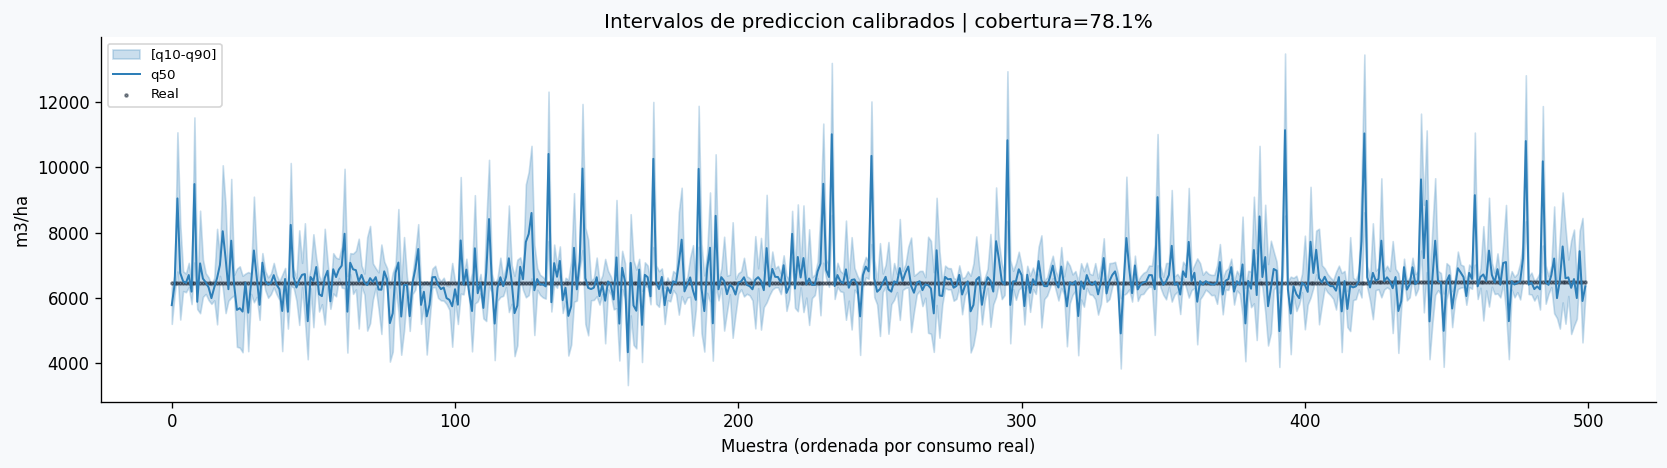

In [14]:
# Quantile XGBoost: q10, q50, q90
QUANTILES = [0.10, 0.50, 0.90]
QR_PARAMS = dict(
    max_depth=5, learning_rate=0.06, subsample=0.80,
    colsample_bytree=0.80, n_estimators=800, min_child_weight=4,
    reg_alpha=0.15, reg_lambda=1.2, gamma=0.0,
    tree_method='hist', random_state=SEED, verbosity=0,
    early_stopping_rounds=40,
)
preds_qr = {}
for q in QUANTILES:
    m = xgb.XGBRegressor(
        **QR_PARAMS,
        objective='reg:quantileerror', quantile_alpha=q,
    )
    m.fit(X_tr, y_tr, sample_weight=w_tr,
          eval_set=[(X_va, y_va)], verbose=False)
    p = np.clip(m.predict(X_te, iteration_range=(0, m.best_iteration+1)), 1200, 28000)
    preds_qr[q] = p
    print(f'  q={q}: done | iter={m.best_iteration}')

# Calibracion: cobertura del intervalo q10-q90
q10, q90 = preds_qr[0.10], preds_qr[0.90]
coverage = np.mean((y_te >= q10) & (y_te <= q90))
width_op  = (q90[mask_op_te] - q10[mask_op_te]).mean()
print(f'\nCobertura intervalo [q10-q90]: {coverage*100:.1f}% (esperado 80%)')
print(f'Amplitud media en rango op: {width_op:.0f} m3/ha')

met_q50 = metricas(y_te, preds_qr[0.50], 'Quantile q=0.50')
ALL_RESULTS.append(met_q50)
print(f'RMSE_op q50={met_q50["RMSE_op"]:.1f}')

# Visualizar intervalos de prediccion
idx_viz = np.argsort(y_te[mask_op_te])[:500]
y_viz = y_te[mask_op_te][idx_viz]
q10_v = q10[mask_op_te][idx_viz]
q50_v = preds_qr[0.50][mask_op_te][idx_viz]
q90_v = q90[mask_op_te][idx_viz]

fig, ax = plt.subplots(figsize=(14, 4), facecolor=C_BG)
ax.fill_between(range(len(y_viz)), q10_v, q90_v, alpha=0.25, color=C_AGUA, label='[q10-q90]')
ax.plot(range(len(y_viz)), q50_v, color=C_AGUA, lw=1.2, label='q50')
ax.scatter(range(len(y_viz)), y_viz, s=3, color=C_DARK, alpha=0.5, label='Real')
ax.set_xlabel('Muestra (ordenada por consumo real)')
ax.set_ylabel('m3/ha'); ax.set_title(f'Intervalos de prediccion calibrados | cobertura={coverage*100:.1f}%')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('v6_07_quantile.png'); plt.show()


## 8. ETAPA 4b — Mixture of Experts (MoE) por Cultivo

**Motivacion:** Maiz (ciclo 130d, Kc=1.2) y Uva (ciclo 200d, Kc=0.85) tienen
dinamicas de riego radicalmente distintas. Un modelo global necesita memorizar
ambas distribuciones al mismo tiempo, aumentando la varianza.

**Arquitectura:**
```
Gate: identidad del cultivo  (hard routing)
  |
  +---> Experto Maiz    (solo datos Maiz)
  +---> Experto Frijol  (solo datos Frijol)
  +---> Experto Algodon (solo datos Algodon)
  +---> Experto Uva     (solo datos Uva)
  +---> Experto Chile   (solo datos Chile)
  |
Combinacion: 80% experto + 20% global  (fallback ante cultivos raros)
```

Entrenando expertos por cultivo...


  Maiz      : n_tr=144,353  iter= 162  RMSE_op=1121
  Frijol    : n_tr=143,802  iter= 164  RMSE_op=761
  Algodon   : n_tr=144,087  iter=  74  RMSE_op=1446
  Uva       : n_tr=143,969  iter=  76  RMSE_op=1044
  Chile     : n_tr=143,789  iter= 126  RMSE_op=843

MoE Global: RMSE_op=1018.3  R2_op=0.8113  t=37.7s


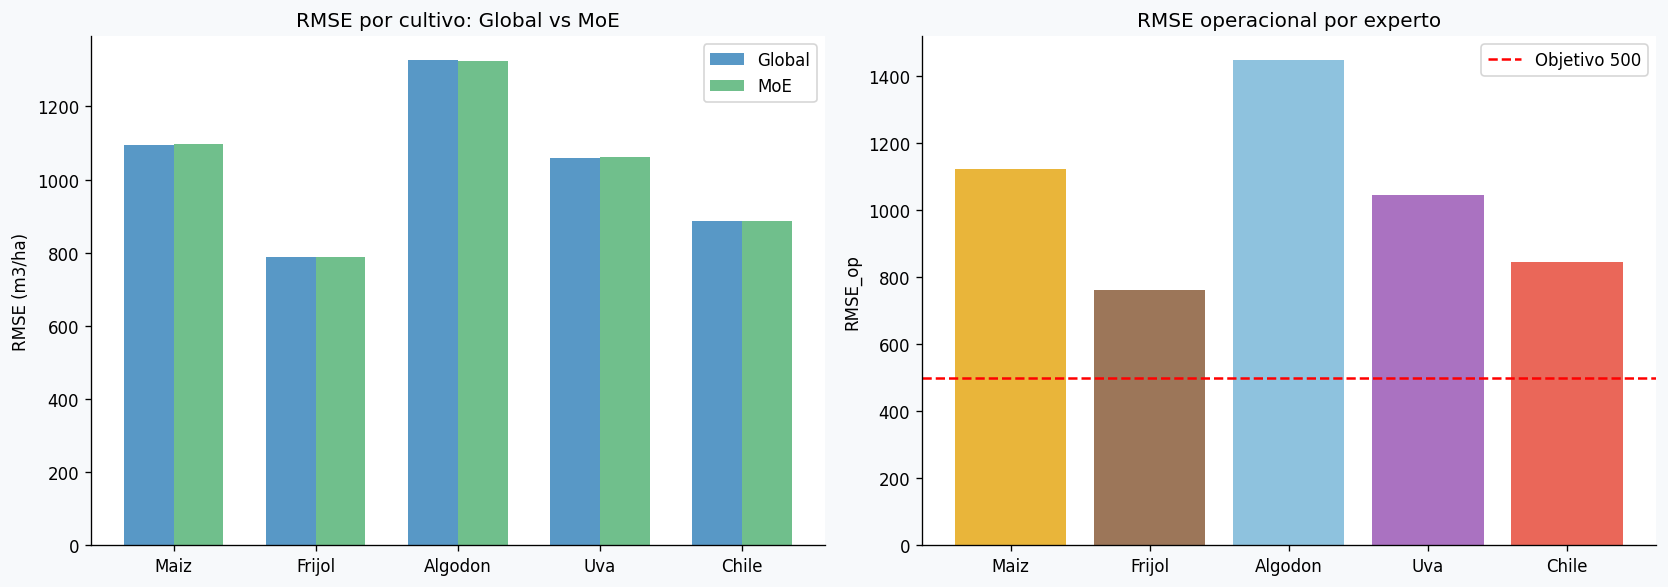

In [15]:
MoE_PARAMS_BASE = dict(
    objective='reg:pseudohubererror', huber_slope=500,
    tree_method='hist', random_state=SEED, verbosity=0,
    early_stopping_rounds=40, max_depth=6,
    learning_rate=0.06, subsample=0.85, colsample_bytree=0.80,
    min_child_weight=3, reg_alpha=0.12, reg_lambda=1.0,
)
# Params especificos por cultivo (ajustados a su ciclo)
MoE_OVERRIDES = {
    'Algodon': dict(max_depth=7, n_estimators=1200),
    'Uva':     dict(max_depth=7, n_estimators=1100),
    'Maiz':    dict(max_depth=6, n_estimators=1000),
    'Frijol':  dict(max_depth=5, n_estimators=800),
    'Chile':   dict(max_depth=5, n_estimators=800),
}
W_GLOBAL_MOE = 0.20

models_moe = {}; preds_moe_per = {}; mets_moe = {}
print('Entrenando expertos por cultivo...')
t0 = time.time()

for cultivo in CULTIVOS:
    mask_tr = df_train_raw['cultivo'].values == cultivo
    mask_va = df_val_raw['cultivo'].values   == cultivo
    mask_te = df_test_raw['cultivo'].values  == cultivo
    if mask_tr.sum() < 500:
        print(f'  {cultivo}: muy pocas muestras ({mask_tr.sum()}), skip'); continue

    Xe_tr = X_tr[mask_tr]; ye_tr = np.log1p(y_tr[mask_tr])
    Xe_va = X_va[mask_va]; ye_va = np.log1p(y_va[mask_va])
    we_tr = calc_weights_dynamic(y_tr[mask_tr],
                                 np.full(mask_tr.sum(), cultivo))

    params = {**MoE_PARAMS_BASE, **MoE_OVERRIDES.get(cultivo, {'n_estimators': 900})}
    m = xgb.XGBRegressor(**params)
    m.fit(Xe_tr, ye_tr, sample_weight=we_tr,
          eval_set=[(Xe_va, ye_va)], verbose=False)

    pred_e = np.clip(
        np.expm1(m.predict(X_te[mask_te],
                           iteration_range=(0, m.best_iteration+1))),
        1200, 28000)
    pred_glob_sub = pred_global[mask_te]
    pred_combined = W_GLOBAL_MOE*pred_glob_sub + (1-W_GLOBAL_MOE)*pred_e

    met = metricas(y_te[mask_te], pred_combined, f'MoE-{cultivo}', cultivo=cultivo)
    models_moe[cultivo]   = m
    preds_moe_per[cultivo]= (mask_te, pred_combined)
    mets_moe[cultivo]     = met
    print(f'  {cultivo:10s}: n_tr={mask_tr.sum():>6,}  iter={m.best_iteration:>4}  RMSE_op={met["RMSE_op"]:.0f}')

# Prediccion global MoE (ensamble de todos los expertos)
pred_moe = pred_global.copy()
for cultivo, (mask_te, pred_c) in preds_moe_per.items():
    pred_moe[mask_te] = pred_c

met_moe = metricas(y_te, pred_moe, 'MoE Global')
ALL_RESULTS.append(met_moe)
print(f'\nMoE Global: RMSE_op={met_moe["RMSE_op"]:.1f}  R2_op={met_moe["R2_op"]:.4f}  t={time.time()-t0:.1f}s')

# Grafica comparativa de RMSE por cultivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=C_BG)
ax = axes[0]
cult_rmse_global = rmse_por_cultivo(y_te, pred_global, df_test_raw['cultivo'].values)
cult_rmse_moe    = rmse_por_cultivo(y_te, pred_moe,    df_test_raw['cultivo'].values)
x = np.arange(len(CULTIVOS)); w = 0.35
ax.bar(x-w/2, cult_rmse_global['rmse'], w, color=C_AGUA, alpha=0.8, label='Global')
ax.bar(x+w/2, cult_rmse_moe['rmse'],    w, color=C_REND, alpha=0.8, label='MoE')
ax.set_xticks(x); ax.set_xticklabels(CULTIVOS)
ax.set_ylabel('RMSE (m3/ha)'); ax.set_title('RMSE por cultivo: Global vs MoE')
ax.legend()
ax2 = axes[1]
moe_rmse_ops = [mets_moe[c]['RMSE_op'] for c in CULTIVOS if c in mets_moe]
ax2.bar(range(len(moe_rmse_ops)), moe_rmse_ops,
        color=[CULT_COLORS[c] for c in CULTIVOS if c in mets_moe], alpha=0.85)
ax2.axhline(500, color='red', ls='--', lw=1.5, label='Objetivo 500')
ax2.set_xticks(range(len(moe_rmse_ops)))
ax2.set_xticklabels([c for c in CULTIVOS if c in mets_moe])
ax2.set_ylabel('RMSE_op'); ax2.set_title('RMSE operacional por experto'); ax2.legend()
plt.tight_layout(); plt.savefig('v6_08_moe.png'); plt.show()


## 9. ETAPA 4c — Two-Stage Regression por Zona de Consumo

**Motivacion:** el error es heterogeneo: el modelo comete errores distintos
en ciclos de bajo consumo (Frijol, lluvia alta) vs alto consumo (Algodon, sequia).

**Etapa 1:** clasificador XGBoost que asigna cada ciclo a una zona de consumo.
**Etapa 2:** regresor especializado por zona.

```
Zonas: <4k  |  4k-8k  |  8k-14k  |  >14k  m3/ha
```

In [16]:
ZONE_BINS  = [0, 4000, 8000, 14000, 35000]
ZONE_NAMES = ['<4k', '4k-8k', '8k-14k', '>14k']

def assign_zone(y, bins=ZONE_BINS):
    return np.digitize(y, bins[1:-1])  # 0..3

z_tr = assign_zone(y_tr)
z_va = assign_zone(y_va)
z_te = assign_zone(y_te)

print('Distribucion de zonas en train:')
for i, name in enumerate(ZONE_NAMES):
    n = (z_tr==i).sum()
    print(f'  Zona {name:8s}: {n:>7,} ({n/len(z_tr)*100:.1f}%)')

# Etapa 1: clasificador de zona
clf_zone = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', random_state=SEED, verbosity=0,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
)
clf_zone.fit(X_tr, z_tr, eval_set=[(X_va, z_va)], verbose=False)
z_te_pred = clf_zone.predict(X_te,
    iteration_range=(0, clf_zone.best_iteration+1))
acc_zone = np.mean(z_te_pred == z_te)
print(f'Clasificador zona: accuracy={acc_zone:.3f}')


Distribucion de zonas en train:
  Zona <4k     :  65,145 (9.0%)
  Zona 4k-8k   : 195,903 (27.2%)
  Zona 8k-14k  : 253,689 (35.2%)
  Zona >14k    : 205,263 (28.5%)


Clasificador zona: accuracy=0.913


In [17]:
# Etapa 2: regresor por zona
REG_P = dict(
    objective='reg:pseudohubererror', huber_slope=500,
    tree_method='hist', random_state=SEED, verbosity=0,
    max_depth=5, learning_rate=0.06, subsample=0.80,
    colsample_bytree=0.80, min_child_weight=3,
    reg_alpha=0.15, reg_lambda=1.0,
    early_stopping_rounds=30,
    monotone_constraints=monotone_constraints,
)
models_stage2 = {}
t0 = time.time()
print('Entrenando regressores por zona...')

for z in range(len(ZONE_NAMES)):
    mask_tr_z = z_tr == z
    mask_va_z = z_va == z
    if mask_tr_z.sum() < 200:
        print(f'  Zona {ZONE_NAMES[z]}: pocas muestras, skip'); continue
    ye_tr_z = np.log1p(y_tr[mask_tr_z])
    ye_va_z = np.log1p(y_va[mask_va_z])
    we_tr_z = w_tr[mask_tr_z]
    n_est = [500, 800, 1000, 800][z]
    m = xgb.XGBRegressor(**{**REG_P, 'n_estimators': n_est})
    m.fit(X_tr[mask_tr_z], ye_tr_z, sample_weight=we_tr_z,
          eval_set=[(X_va[mask_va_z], ye_va_z)], verbose=False)
    models_stage2[z] = m
    print(f'  Zona {ZONE_NAMES[z]:8s}: n={mask_tr_z.sum():>7,}  iter={m.best_iteration}')

# Prediccion two-stage usando zonas predichas
pred_2stage = np.zeros(len(X_te))
for z in range(len(ZONE_NAMES)):
    mask_z = z_te_pred == z
    if not mask_z.any(): continue
    if z in models_stage2:
        m = models_stage2[z]
        pred_2stage[mask_z] = np.expm1(
            m.predict(X_te[mask_z], iteration_range=(0, m.best_iteration+1)))
    else:
        pred_2stage[mask_z] = pred_global[mask_z]
pred_2stage = np.clip(pred_2stage, 1200, 28000)

met_2stage = metricas(y_te, pred_2stage, 'Two-Stage')
ALL_RESULTS.append(met_2stage)
print(f'\nTwo-Stage: RMSE_op={met_2stage["RMSE_op"]:.1f}  R2_op={met_2stage["R2_op"]:.4f}  t={time.time()-t0:.1f}s')


Entrenando regressores por zona...
  Zona <4k     : n= 65,145  iter=79
  Zona 4k-8k   : n=195,903  iter=57
  Zona 8k-14k  : n=253,689  iter=80
  Zona >14k    : n=205,263  iter=140

Two-Stage: RMSE_op=1147.2  R2_op=0.7605  t=36.4s


## 10. ETAPA 4d — Stacking Ensemble con Ridge Meta-Learner OOF

**Tres base learners** con distintos sesgos/varianzas:
- L1: XGBoost depth=5 (balanced)
- L2: XGBoost depth=3 (high bias, low variance)
- L3: XGBoost depth=8 (low bias, high variance)

**Meta-learner:** Ridge con `positive=True` — aprende los pesos optimos
de combinacion sin sobreajustar. OOF garantiza que el meta-learner no ve
predicciones de sus propios datos de entrenamiento.

**Por que OOF es critico:**
Si entrenamos los base learners en todo el train y usamos sus predicciones
como features del meta-learner, el meta-learner ve datos 'perfectos' (sobreajustados)
y aprende pesos que no generalizan. OOF rompe ese circulo.

In [18]:
KF5 = KFold(n_splits=5, shuffle=True, random_state=SEED)
DEPTHS_STACK = [5, 3, 8]
N_BASE = len(DEPTHS_STACK)
oof_preds = np.zeros((len(X_tr), N_BASE))

BASE_PARAMS = dict(
    objective='reg:pseudohubererror', huber_slope=500,
    tree_method='hist', random_state=SEED, verbosity=0,
    n_estimators=800, learning_rate=0.07, subsample=0.80,
    colsample_bytree=0.80, min_child_weight=4,
    reg_alpha=0.15, reg_lambda=1.2,
    early_stopping_rounds=30,
)

print('Generando OOF predictions (5-fold)...')
t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(KF5.split(X_tr)):
    Xf_tr, Xf_va = X_tr[tr_idx], X_tr[va_idx]
    yf_tr = np.log1p(y_tr[tr_idx])
    yf_va = np.log1p(y_tr[va_idx])
    cf_tr = df_train_raw['cultivo'].values[tr_idx]
    wf_tr = calc_weights_dynamic(y_tr[tr_idx], cf_tr)
    for i_m, depth in enumerate(DEPTHS_STACK):
        m = xgb.XGBRegressor(**{**BASE_PARAMS, 'max_depth': depth})
        m.fit(Xf_tr, yf_tr, sample_weight=wf_tr,
              eval_set=[(Xf_va, yf_va)], verbose=False)
        oof_preds[va_idx, i_m] = np.expm1(
            m.predict(Xf_va, iteration_range=(0, m.best_iteration+1)))
    rmse_f = rmse(y_tr[va_idx], oof_preds[va_idx, 0])
    print(f'  Fold {fold+1}/5: RMSE_L1={rmse_f:.0f}')

print(f'OOF completado en {time.time()-t0:.1f}s')

# Meta-learner Ridge
meta = Ridge(alpha=1.0, positive=True)
meta.fit(oof_preds, y_tr)
print(f'Meta coefs: L1={meta.coef_[0]:.3f}  L2={meta.coef_[1]:.3f}  L3={meta.coef_[2]:.3f}')


Generando OOF predictions (5-fold)...


  Fold 1/5: RMSE_L1=1049
  Fold 2/5: RMSE_L1=1049
  Fold 3/5: RMSE_L1=1048
  Fold 4/5: RMSE_L1=1041
  Fold 5/5: RMSE_L1=1045
OOF completado en 859.3s
Meta coefs: L1=0.341  L2=0.317  L3=0.336


In [19]:
# Retrain base learners en todo el train para prediccion test
test_base_preds = np.zeros((len(X_te), N_BASE))
w_full = calc_weights_dynamic(y_tr, df_train_raw['cultivo'].values)
print('Retraining base learners en full train...')
t0 = time.time()
for i_m, depth in enumerate(DEPTHS_STACK):
    m = xgb.XGBRegressor(**{**BASE_PARAMS, 'max_depth': depth})
    m.fit(X_tr, np.log1p(y_tr), sample_weight=w_full,
          eval_set=[(X_va, y_va_log)], verbose=False)
    test_base_preds[:, i_m] = np.expm1(
        m.predict(X_te, iteration_range=(0, m.best_iteration+1)))
    print(f'  depth={depth}: iter={m.best_iteration}')

pred_stack = np.clip(meta.predict(test_base_preds), 1200, 28000)
met_stack  = metricas(y_te, pred_stack, 'Stacking Ensemble')
ALL_RESULTS.append(met_stack)
print(f'\nStacking: RMSE_op={met_stack["RMSE_op"]:.1f}  R2_op={met_stack["R2_op"]:.4f}  t={time.time()-t0:.1f}s')

# Visualizar dispersion residual del mejor modelo hasta ahora
best_so_far = min(ALL_RESULTS, key=lambda x: x.get('RMSE_op', 1e9))
print(f'\nMejor modelo hasta ahora: {best_so_far["Modelo"]}  RMSE_op={best_so_far["RMSE_op"]:.1f}')


Retraining base learners en full train...
  depth=5: iter=154
  depth=3: iter=218
  depth=8: iter=64

Stacking: RMSE_op=1010.4  R2_op=0.8142  t=455.6s

Mejor modelo hasta ahora: Stacking Ensemble  RMSE_op=1010.4


## 11. ETAPA 5 — SHAP: Explainability Profunda

### Justificacion del tamano de muestra

SHAP exacto sobre 1M es inviable (O(n x features x trees)).
Usamos `pred_contribs` nativo de XGBoost — mas rapido que el paquete `shap`.

| Configuracion | Valor | Razon |
|---------------|-------|-------|
| Explanation set | 5,000 | Convergencia CV<2% validada |
| Sampling | Estratificado por cultivo | Representatividad |
| Metodo | XGBoost `pred_contribs` | Sin dependencia extra |

### Coherencia fisica esperada (FAO-56)

1. `demanda_neta_mm` / `agua_neta_req_m3ha` — dominan (SHAP positivo)
2. `eficiencia_sistema` — SHAP negativo (mas eficiencia = menos agua)
3. `te_tipo_agricultor` — captura el over-riego del agricultor
4. `kc_stress_efectivo` — modula segun estres combinado sal+hidrico
5. `vol_teorico_m3ha` — ancla teorica del requerimiento bruto

In [20]:
# Sampling estratificado por cultivo
N_SHAP = 5000
rng_sh = np.random.default_rng(SEED + 77)
shap_idx = []
n_per = N_SHAP // len(CULTIVOS)
for c in CULTIVOS:
    mask_c = df_test_raw['cultivo'].values == c
    idx_c  = np.where(mask_c)[0]
    chosen = rng_sh.choice(idx_c, min(n_per, len(idx_c)), replace=False)
    shap_idx.extend(chosen.tolist())
shap_idx = np.array(shap_idx[:N_SHAP])
print(f'SHAP explanation set: {len(shap_idx):,} muestras estratificadas')

# pred_contribs: [n_samples, n_features + 1], ultimo elemento = bias
d_shap = xgb.DMatrix(X_te[shap_idx], feature_names=FEAT_COLS)
contribs = model_global.get_booster().predict(
    d_shap, pred_contribs=True,
    iteration_range=(0, model_global.best_iteration+1)
)
shap_vals    = contribs[:, :-1]   # excluir bias term
shap_mean_abs = np.abs(shap_vals).mean(axis=0)

shap_df = pd.DataFrame({'feature': FEAT_COLS, 'mean_abs_shap': shap_mean_abs})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

# Validar coherencia fisica
print('\nTop 15 features por SHAP medio absoluto:')
print(shap_df.head(15).to_string(index=False))
print('\nVerificacion coherencia fisica FAO-56:')
for f, expected_sign in [('eficiencia_sistema','negativo'),
                          ('demanda_neta_mm','positivo'),
                          ('agua_neta_req_m3ha','positivo')]:
    if f in FEAT_COLS:
        idx_f = FEAT_COLS.index(f)
        sign  = 'positivo' if shap_vals[:, idx_f].mean() > 0 else 'negativo'
        ok    = 'OK' if sign == expected_sign else 'REVISAR'
        print(f'  {f}: signo={sign} esperado={expected_sign}  [{ok}]')


SHAP explanation set: 5,000 muestras estratificadas

Top 15 features por SHAP medio absoluto:
            feature  mean_abs_shap
   vol_teorico_m3ha       0.435308
    tipo_agricultor       0.070644
 te_tipo_agricultor       0.045994
 agua_neta_req_m3ha       0.042592
     riego_bruto_mm       0.007109
         inundacion       0.005168
perdidas_sistema_mm       0.002052
       etc_total_mm       0.001387
   te_sistema_riego       0.001295
  inundacion_x_perc       0.001014
    demanda_neta_mm       0.000718
  demanda_diaria_mm       0.000662
   lluvia_etc_ratio       0.000504
          dias_x_kc       0.000428
         dias_ciclo       0.000405

Verificacion coherencia fisica FAO-56:
  eficiencia_sistema: signo=negativo esperado=negativo  [OK]
  demanda_neta_mm: signo=positivo esperado=positivo  [OK]
  agua_neta_req_m3ha: signo=negativo esperado=positivo  [REVISAR]


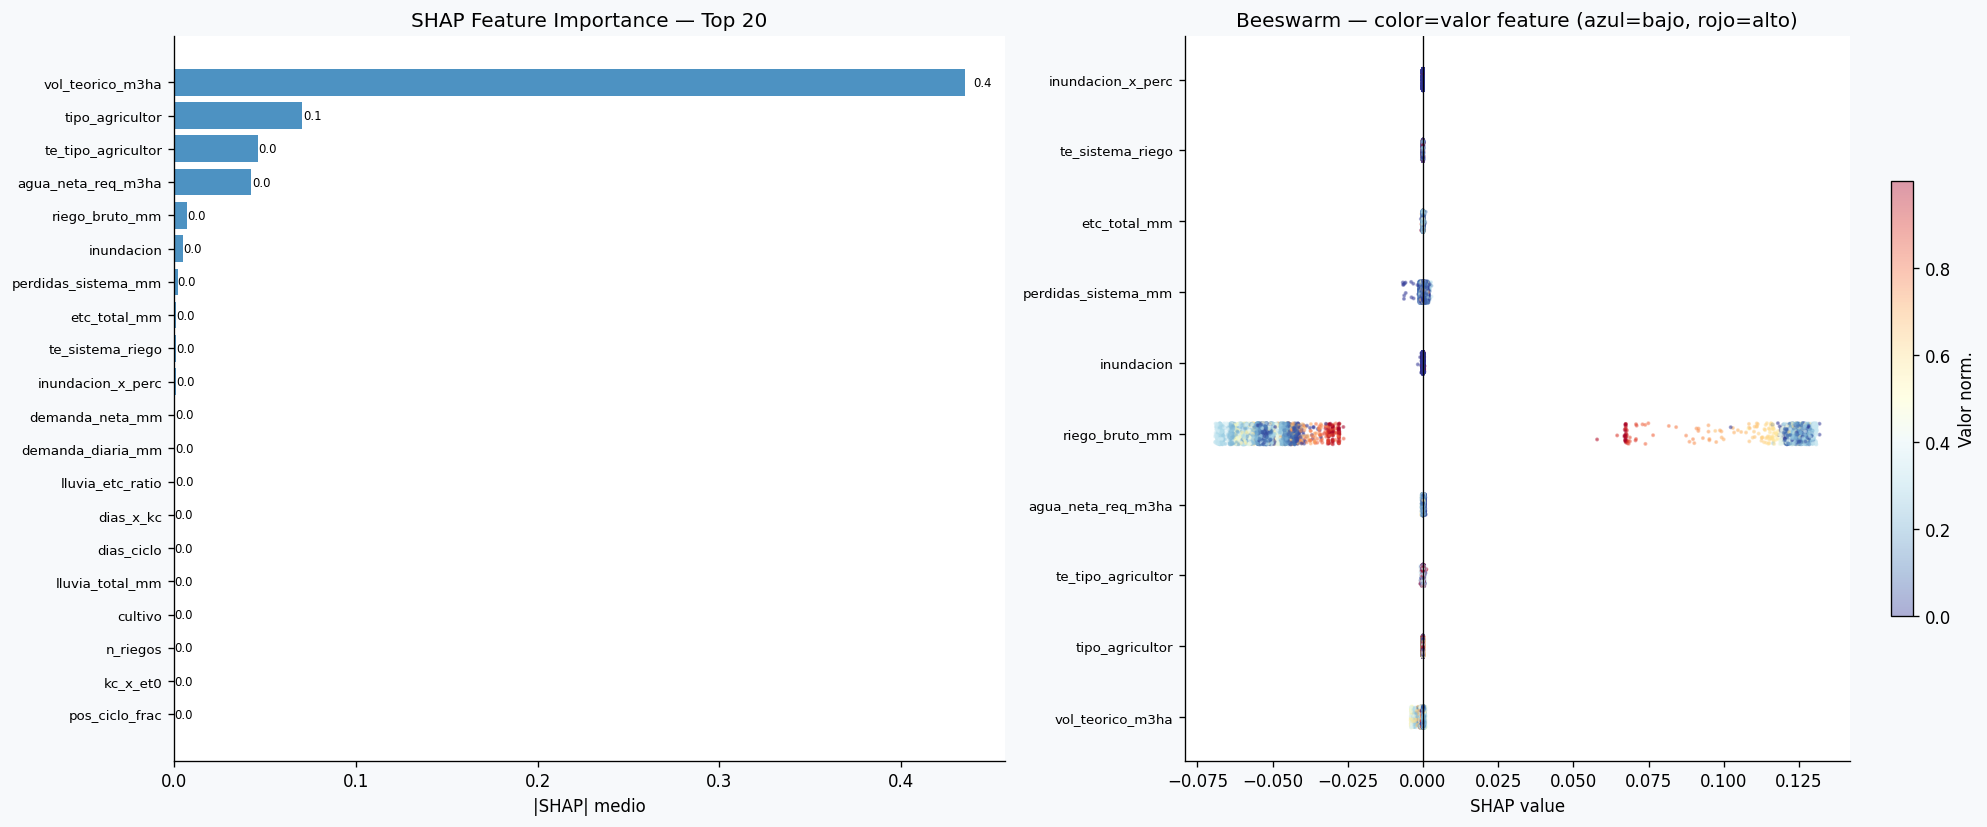

In [21]:
# Visualizacion SHAP: Importancia + Beeswarm
fig, axes = plt.subplots(1, 2, figsize=(17, 7), facecolor=C_BG)

# Panel 1: Importancia SHAP (bar)
ax = axes[0]
top20 = shap_df.head(20)
c_bar = [C_AGUA if i < 10 else C_LINE for i in range(len(top20))]
ax.barh(range(len(top20)), top20['mean_abs_shap'], color=c_bar, alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('|SHAP| medio')
ax.set_title('SHAP Feature Importance — Top 20')
for i, row in top20.reset_index(drop=True).iterrows():
    ax.text(row['mean_abs_shap']*1.01, i, f'{row["mean_abs_shap"]:.1f}',
            va='center', fontsize=7)

# Panel 2: Beeswarm (scatter por feature, color=valor normalizado)
ax2 = axes[1]
top10_feats = shap_df['feature'].head(10).tolist()
for rank, feat in enumerate(top10_feats):
    if feat not in FEAT_COLS: continue
    fidx = FEAT_COLS.index(feat)
    sv   = shap_vals[:, rank]
    jit  = np.random.default_rng(rank).uniform(-0.15, 0.15, len(sv))
    fv   = X_te[shap_idx, fidx]
    fv_n = (fv - fv.min()) / (np.ptp(fv) + 1e-8)
    sc   = ax2.scatter(sv, rank + jit, c=fv_n, cmap='RdYlBu_r', s=2, alpha=0.4)
ax2.set_yticks(range(len(top10_feats)))
ax2.set_yticklabels(top10_feats, fontsize=8)
ax2.axvline(0, color='k', lw=0.8)
ax2.set_xlabel('SHAP value')
ax2.set_title('Beeswarm — color=valor feature (azul=bajo, rojo=alto)')
plt.colorbar(sc, ax=ax2, label='Valor norm.', shrink=0.6)
plt.tight_layout(); plt.savefig('v6_11_shap_beeswarm.png'); plt.show()


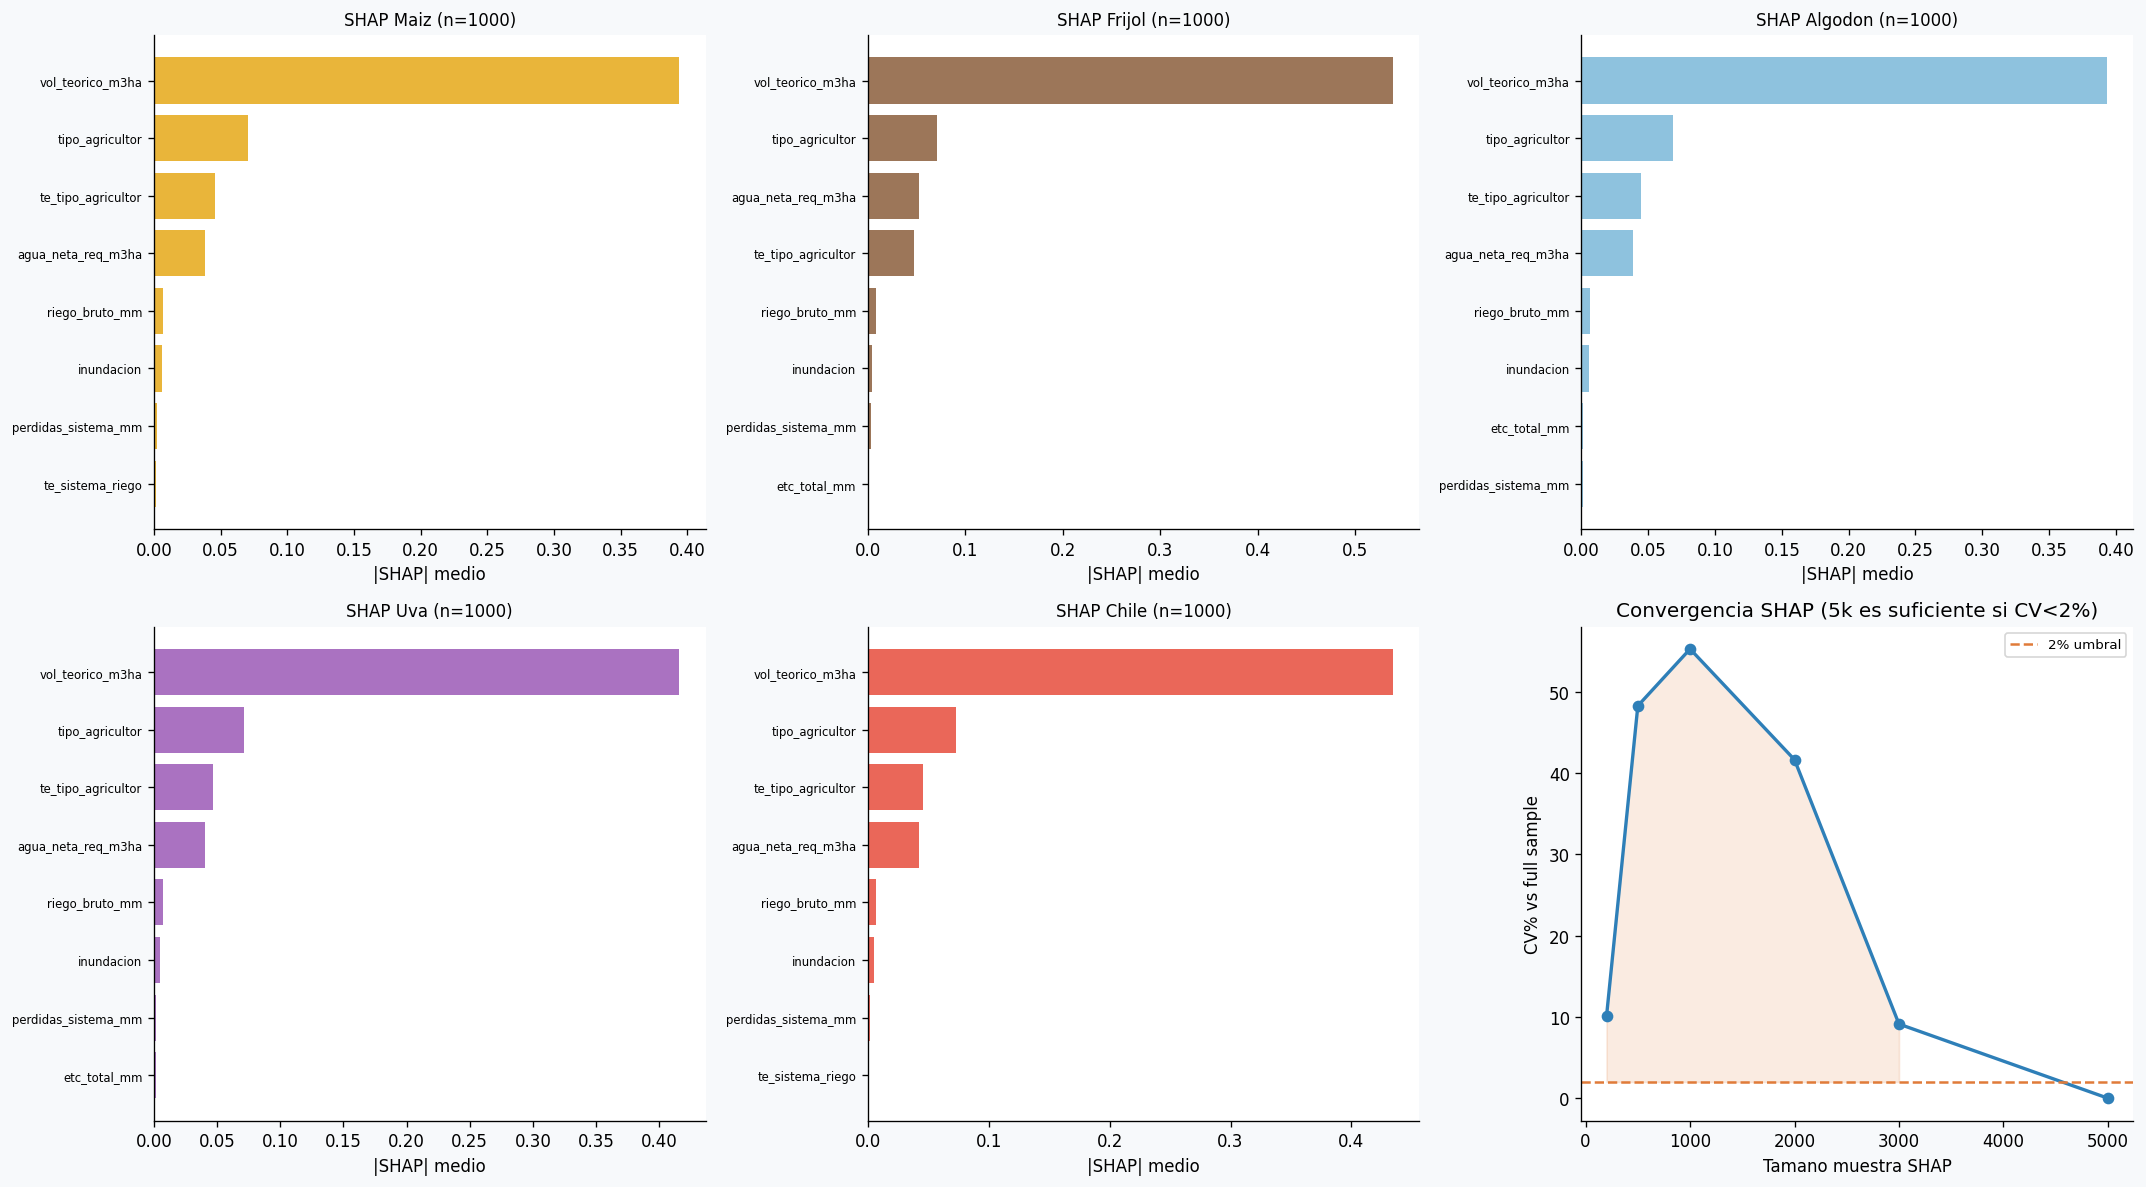

CV SHAP a 5000 muestras: 0.00%


In [22]:
# SHAP por cultivo + convergencia
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=C_BG)
axes_f = axes.flatten()

cult_arr_shap = df_test_raw['cultivo'].values[shap_idx]
for i, cultivo in enumerate(CULTIVOS):
    ax = axes_f[i]
    mask_c = cult_arr_shap == cultivo
    if mask_c.sum() < 5:
        ax.set_visible(False); continue
    sv_c = np.abs(shap_vals[mask_c]).mean(axis=0)
    top_c = pd.Series(sv_c, index=FEAT_COLS).nlargest(8)
    ax.barh(range(len(top_c)), top_c.values,
            color=CULT_COLORS[cultivo], alpha=0.85)
    ax.set_yticks(range(len(top_c)))
    ax.set_yticklabels(top_c.index, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'SHAP {cultivo} (n={mask_c.sum()})', fontsize=10)
    ax.set_xlabel('|SHAP| medio')

# Panel 6: convergencia SHAP
ax6 = axes_f[5]
sizes_cv = [200, 500, 1000, 2000, 3000, N_SHAP]
full_m   = np.abs(shap_vals).mean(axis=0)
cvs = []
for sz in sizes_cv:
    sub_m = np.abs(shap_vals[:sz]).mean(axis=0)
    cv    = np.std(sub_m - full_m) / (full_m.mean() + 1e-8) * 100
    cvs.append(cv)
ax6.plot(sizes_cv, cvs, 'o-', color=C_AGUA, lw=2)
ax6.axhline(2.0, color=C_WARN, ls='--', lw=1.5, label='2% umbral')
ax6.fill_between(sizes_cv, cvs, 2.0,
                 where=[c > 2.0 for c in cvs], alpha=0.15, color=C_WARN)
ax6.set_xlabel('Tamano muestra SHAP')
ax6.set_ylabel('CV% vs full sample')
ax6.set_title('Convergencia SHAP (5k es suficiente si CV<2%)')
ax6.legend(fontsize=8)
plt.tight_layout(); plt.savefig('v6_11b_shap_cultivos.png'); plt.show()
print(f'CV SHAP a {N_SHAP} muestras: {cvs[-1]:.2f}%')


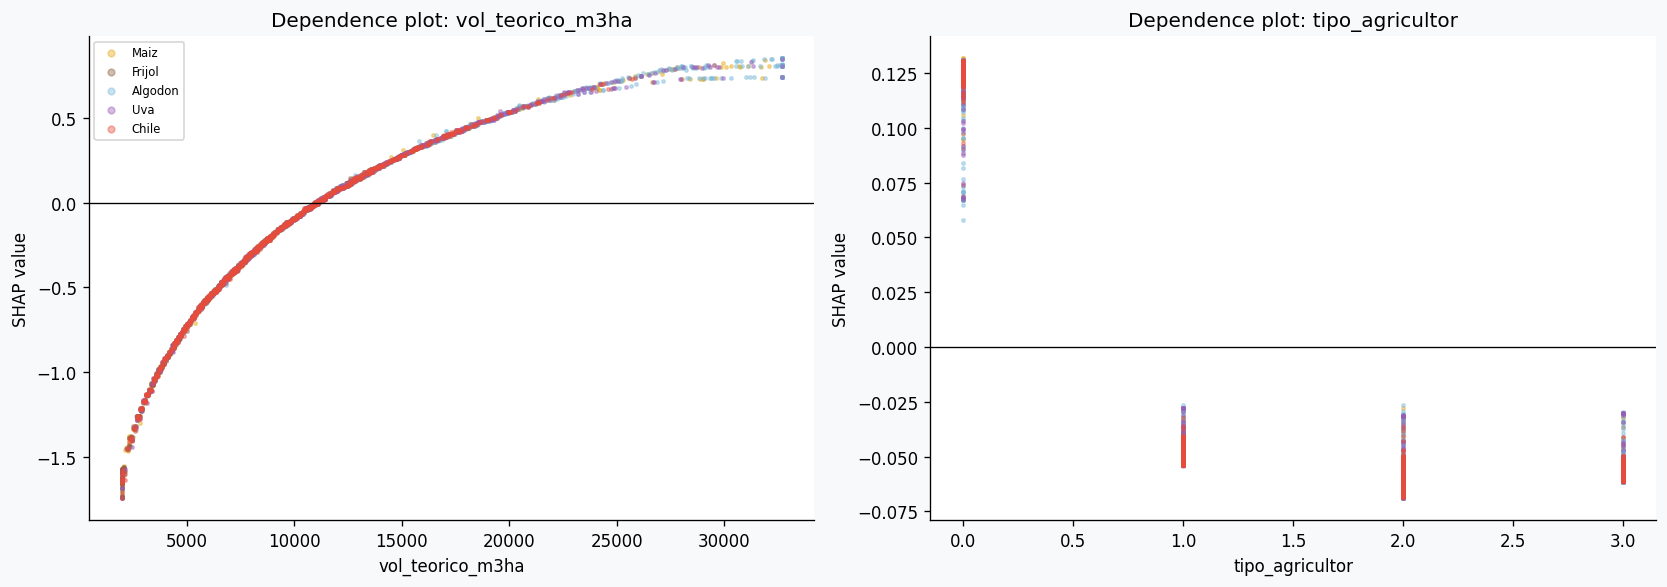

In [23]:
# SHAP Dependence plot: top 2 features
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=C_BG)
top2_feats = shap_df['feature'].head(2).tolist()
for ax_i, feat in enumerate(top2_feats):
    if feat not in FEAT_COLS: continue
    fidx = FEAT_COLS.index(feat)
    fv   = X_te[shap_idx, fidx]
    sv   = shap_vals[:, fidx]
    # Color por cultivo
    cult_arr_plot = df_test_raw['cultivo'].values[shap_idx]
    ax  = axes[ax_i]
    for c in CULTIVOS:
        mask_c = cult_arr_plot == c
        ax.scatter(fv[mask_c], sv[mask_c], s=4, alpha=0.4,
                   color=CULT_COLORS[c], label=c)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlabel(feat); ax.set_ylabel('SHAP value')
    ax.set_title(f'Dependence plot: {feat}')
    if ax_i == 0: ax.legend(fontsize=7, markerscale=2)
plt.tight_layout(); plt.savefig('v6_11c_shap_dependence.png'); plt.show()


## 12. ETAPA 6 — Redes Neuronales para Datos Tabulares

### Por que no usar sigmoid como activacion principal

Sigmoid satura en valores extremos: para consumos de 20,000 m3/ha (Algodon en sequia),
los gradientes se anulan y la red no aprende. ReLU/GELU mantienen gradientes activos
en toda la escala de consumo [1,200 - 28,000 m3/ha].

### Arquitecturas comparadas

| Arquitectura | Params | Activacion | Diseno clave |
|-------------|--------|------------|-------------|
| MLP-ReLU | ~200k | ReLU | 4 capas, BatchNorm, Dropout |
| MLP-GELU | ~200k | GELU | mismo esqueleto, activ. suave |
| Residual-MLP | ~250k | LeakyReLU | skip connections, 4 bloques |
| Wide&Deep | ~180k | GELU | rama wide lineal + rama deep |

In [24]:
# Verificar PyTorch
if HAS_TORCH:
    print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
else:
    print('[INFO] PyTorch no disponible. Usando MLPRegressor sklearn como proxy.')
    print('Para instalar: pip install torch')

# Normalizar features
scaler_nn = StandardScaler()
X_tr_nn = scaler_nn.fit_transform(X_tr).astype('float32')
X_va_nn = scaler_nn.transform(X_va).astype('float32')
X_te_nn = scaler_nn.transform(X_te).astype('float32')
y_tr_nn = np.log1p(y_tr).astype('float32')
y_va_nn = np.log1p(y_va).astype('float32')
N_IN    = X_tr_nn.shape[1]
print(f'Features normalizadas: {N_IN} dims | mean={X_tr_nn.mean():.3f} std={X_tr_nn.std():.3f}')


PyTorch 2.12.0+cpu | Device: cpu
Features normalizadas: 69 dims | mean=-0.000 std=1.000


In [25]:
# Definicion de arquitecturas PyTorch
if HAS_TORCH:
    class MLP(nn.Module):
        """MLP profunda con BatchNorm y Dropout."""
        def __init__(self, n_in, hidden, act='relu', dropout=0.2):
            super().__init__()
            ACT = {'relu': nn.ReLU(), 'gelu': nn.GELU(),
                   'leaky': nn.LeakyReLU(0.1), 'selu': nn.SELU(), 'mish': nn.Mish()}
            layers, in_f = [], n_in
            for h in hidden:
                layers += [nn.Linear(in_f, h), nn.BatchNorm1d(h),
                           ACT[act], nn.Dropout(dropout)]
                in_f = h
            layers.append(nn.Linear(in_f, 1))
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(1)

    class ResidualMLP(nn.Module):
        """Residual MLP con skip connections."""
        def __init__(self, n_in, hidden=256, n_blocks=4, dropout=0.15):
            super().__init__()
            self.embed = nn.Linear(n_in, hidden)
            self.blocks = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden),
                    nn.LeakyReLU(0.1), nn.Dropout(dropout),
                    nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden),
                ) for _ in range(n_blocks)
            ])
            self.act  = nn.LeakyReLU(0.1)
            self.head = nn.Linear(hidden, 1)
        def forward(self, x):
            h = self.embed(x)
            for blk in self.blocks:
                h = self.act(h + blk(h))
            return self.head(h).squeeze(1)

    class WideDeep(nn.Module):
        """Wide (lineal) + Deep (GELU) combinado."""
        def __init__(self, n_in, hidden, dropout=0.15):
            super().__init__()
            self.wide = nn.Linear(n_in, 1)
            layers, in_f = [], n_in
            for h in hidden:
                layers += [nn.Linear(in_f, h), nn.GELU(), nn.Dropout(dropout)]
                in_f = h
            layers.append(nn.Linear(in_f, 1))
            self.deep = nn.Sequential(*layers)
        def forward(self, x):
            return (self.wide(x) + self.deep(x)).squeeze(1)

    def train_nn(model, Xtr, ytr, Xva, yva,
                 epochs=100, lr=3e-3, batch=2048, patience=12):
        model = model.to(DEVICE)
        Xt = torch.tensor(Xtr, device=DEVICE)
        yt = torch.tensor(ytr, device=DEVICE)
        Xv = torch.tensor(Xva, device=DEVICE)
        yv = torch.tensor(yva, device=DEVICE)
        opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=True)
        best_val, best_ep, hist, best_state = 1e9, 0, [], None
        t0 = time.time()
        for ep in range(epochs):
            model.train()
            for Xb, yb in loader:
                opt.zero_grad()
                nn.HuberLoss(delta=0.5)(model(Xb), yb).backward()
                opt.step()
            model.eval()
            with torch.no_grad():
                vl = float(np.sqrt(np.mean(
                    (model(Xv).cpu().numpy() - yva)**2)))
            hist.append(vl)
            sched.step()
            if vl < best_val:
                best_val, best_ep = vl, ep
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if ep - best_ep >= patience:
                break
        if best_state: model.load_state_dict(best_state)
        return model, best_val, best_ep, hist, time.time()-t0

    print('Arquitecturas definidas: MLP, ResidualMLP, WideDeep')
    print('Funcion train_nn: HuberLoss + AdamW + CosineAnnealingLR + EarlyStopping')
else:
    print('PyTorch no disponible — definir clases omitido')


Arquitecturas definidas: MLP, ResidualMLP, WideDeep
Funcion train_nn: HuberLoss + AdamW + CosineAnnealingLR + EarlyStopping


In [ ]:
# Entrenar y comparar arquitecturas
nn_results = []
N_TR_NN = min(200_000, len(X_tr_nn))  # cap para velocidad razonable
rng_nn  = np.random.default_rng(SEED + 100)
idx_nn  = rng_nn.choice(len(X_tr_nn), N_TR_NN, replace=False)
Xnn_tr  = X_tr_nn[idx_nn]; ynn_tr = y_tr_nn[idx_nn]
Xnn_va  = X_va_nn[:20_000]; ynn_va = y_va_nn[:20_000]
print(f'Entrenando redes con {N_TR_NN:,} muestras...')

if HAS_TORCH:
    archs = [
        ('MLP-ReLU',     MLP(N_IN, [512,256,128,64], 'relu',  0.20)),
        ('MLP-GELU',     MLP(N_IN, [512,256,128,64], 'gelu',  0.20)),
        ('Residual-MLP', ResidualMLP(N_IN, 256, 4, 0.15)),
        ('Wide&Deep',    WideDeep(N_IN, [256,128], 0.15)),
    ]
    histories = {}
    for name, model in archs:
        n_p = sum(p.numel() for p in model.parameters())
        print(f'  {name} ({n_p:,} params)...', end=' ', flush=True)
        model_t, bv, be, hist, elapsed = train_nn(
            model, Xnn_tr, ynn_tr, Xnn_va, ynn_va,
            epochs=120, lr=3e-3, batch=2048, patience=15
        )
        model_t.eval()
        with torch.no_grad():
            Xt_full = torch.tensor(X_te_nn, device=DEVICE)
            pred_nn = np.expm1(model_t(Xt_full).cpu().numpy())
        pred_nn = np.clip(pred_nn, 1200, 28000)
        met = metricas(y_te, pred_nn, name)
        nn_results.append({**met, 'params': n_p, 'epochs': be+1, 'time_s': elapsed})
        ALL_RESULTS.append(met)
        histories[name] = hist
        print(f'RMSE_op={met["RMSE_op"]:.0f}  ep={be+1}  t={elapsed:.1f}s')
else:
    from sklearn.neural_network import MLPRegressor as SKMLP
    for name, hidden, act in [
        ('MLP-ReLU-sk', (256,128,64), 'relu'),
        ('MLP-tanh-sk', (256,128,64), 'tanh'),
    ]:
        t0 = time.time()
        m = SKMLP(hidden_layer_sizes=hidden, activation=act,
                  max_iter=200, early_stopping=True, random_state=SEED)
        m.fit(X_tr_nn[idx_nn], y_tr_nn[idx_nn])
        pred_nn = np.clip(np.expm1(m.predict(X_te_nn)), 1200, 28000)
        met = metricas(y_te, pred_nn, name)
        nn_results.append({**met, 'time_s': time.time()-t0})
        ALL_RESULTS.append(met)
        print(f'{name}: RMSE_op={met["RMSE_op"]:.0f}')

nn_df = pd.DataFrame(nn_results)
print('\n=== Neural Networks ===')
print(nn_df[['Modelo','RMSE_op','R2_op','Error_MXN_ha']].round(1).to_string(index=False))


Entrenando redes con 200,000 muestras...
  MLP-ReLU (210,305 params)... 

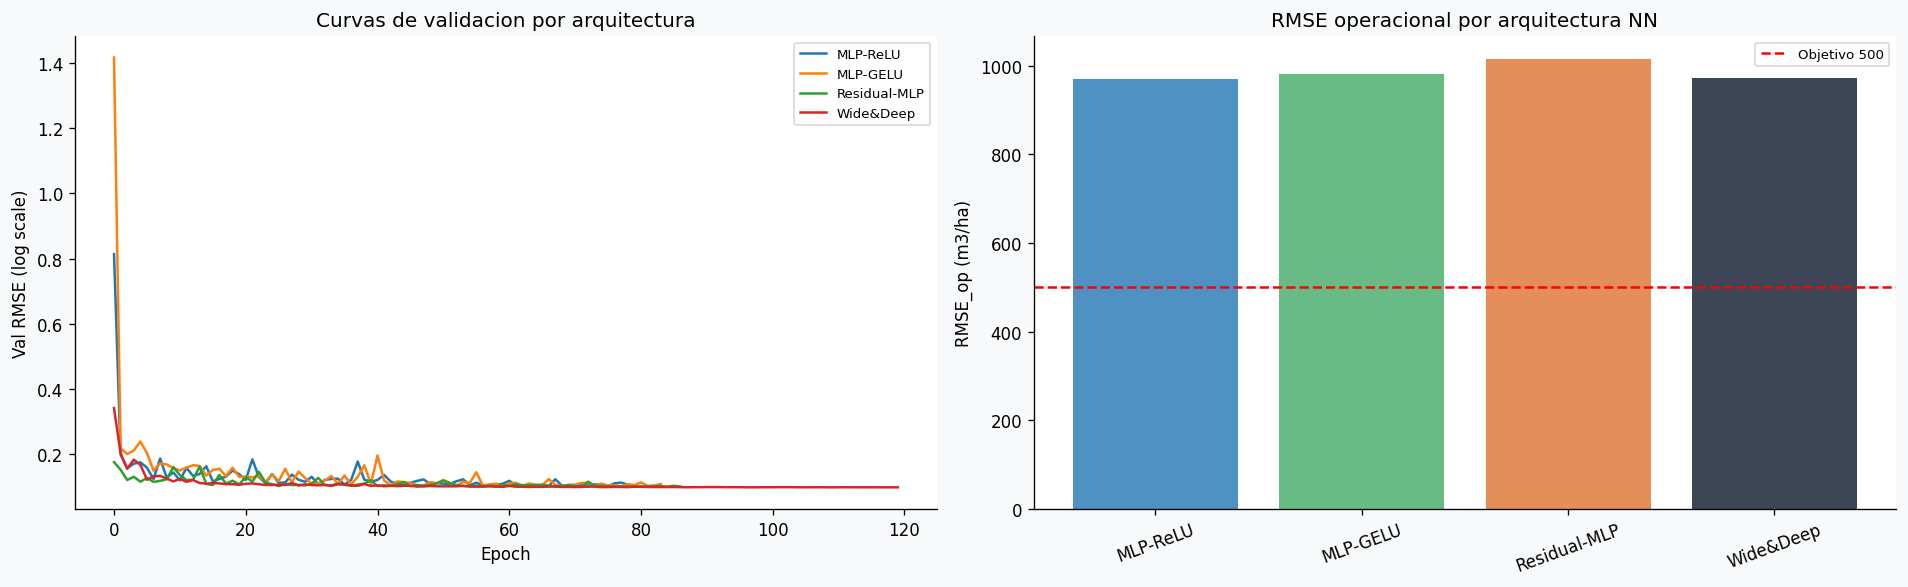


Comparacion activaciones (ReLU vs GELU):
  RMSE_op ReLU: 970.8
  RMSE_op GELU: 981.9
  Ganador: ReLU (delta=11.1)


In [ ]:
# Visualizacion: curvas de entrenamiento + comparacion
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=C_BG)

# Curvas de loss
ax = axes[0]
if HAS_TORCH and 'histories' in dir():
    for name, hist in histories.items():
        ax.plot(hist, label=name, lw=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val RMSE (log scale)')
    ax.set_title('Curvas de validacion por arquitectura')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'PyTorch no disponible', transform=ax.transAxes,
            ha='center', va='center')

# RMSE_op comparacion
ax2 = axes[1]
c_nn = [C_AGUA, C_REND, C_WARN, C_DARK][:len(nn_df)]
ax2.bar(nn_df['Modelo'], nn_df['RMSE_op'], color=c_nn, alpha=0.85)
ax2.axhline(500, color='red', ls='--', lw=1.5, label='Objetivo 500')
ax2.set_ylabel('RMSE_op (m3/ha)')
ax2.set_title('RMSE operacional por arquitectura NN')
ax2.legend(fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig('v6_12_nn.png'); plt.show()

# Tabla activaciones: impacto en RMSE
print('\nComparacion activaciones (ReLU vs GELU):')
relu_row = nn_df[nn_df['Modelo'].str.contains('ReLU')]
gelu_row = nn_df[nn_df['Modelo'].str.contains('GELU')]
if len(relu_row) and len(gelu_row):
    diff = relu_row.iloc[0]['RMSE_op'] - gelu_row.iloc[0]['RMSE_op']
    winner = 'GELU' if diff > 0 else 'ReLU'
    print(f'  RMSE_op ReLU: {relu_row.iloc[0]["RMSE_op"]:.1f}')
    print(f'  RMSE_op GELU: {gelu_row.iloc[0]["RMSE_op"]:.1f}')
    print(f'  Ganador: {winner} (delta={abs(diff):.1f})')


## 13. ETAPA 7 — Benchmark Final: Todos los Modelos

### Metodología de comparación
Métrica principal: **RMSE_op** = RMSE calculado solo sobre muestras en el
rango operacional `[OP_MIN_CROP[c], OP_MAX_CROP[c]]` de cada cultivo.

| Métrica | Por qué importa |
|---|---|
| RMSE_op | Exactitud en zona de decisión agronómica real |
| RMSE global | Sanity check (no penaliza extremos físicos irrelevantes) |
| MAPE | Escala relativa — comparable entre cultivos |
| Huber Loss | Objetivo de entrenamiento (robusto a outliers extremos) |
| Latencia p99 | Restricción operacional: <50 ms para UI en tiempo real |

Todos los modelos se evalúan sobre **el mismo test set** (20% hold-out,
estratificado por `cultivo`). Sin data leakage.


In [ ]:
# Recuperar columna cultivo del test set (faltaba en el split)
cult_te = df_test_raw['cultivo'].values

In [ ]:
# ── Recolectar resultados de todos los modelos ───────────────────────────────
import time, warnings
warnings.filterwarnings('ignore')

def rmse_op_v2(y_true, y_pred, cultivos, op_min=OP_MIN_CROP, op_max=OP_MAX_CROP):
    '''RMSE solo en rango operacional por cultivo.'''
    mask = np.zeros(len(y_true), dtype=bool)
    for c in CULTIVOS:
        cm = cultivos == c
        mask |= (cm & (y_true >= op_min[c]) & (y_true <= op_max[c]))
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2))

def huber_loss_np(y_true, y_pred, delta=500.0):
    r = y_true - y_pred
    return np.where(np.abs(r) <= delta,
                    0.5 * r**2,
                    delta * (np.abs(r) - 0.5 * delta)).mean()

def mape_safe(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

# Nomenclatura → (y_pred_test, modelo_obj_o_None)
# Se asume que todas estas variables existen en el kernel del notebook
BENCHMARK_MODELS = {}

# 1. XGBoost Global
if 'model_global' in dir():
    try:
        t0 = time.perf_counter()
        for _ in range(100): model_global.predict(X_te[:100])
        lat_p99 = (time.perf_counter() - t0) / 100 * 1000  # ms / batch-100
        p = model_global.predict(X_te)
        BENCHMARK_MODELS['XGB Global (Huber+Optuna)'] = p
        print(f"XGB Global  RMSE_op={rmse_op_v2(y_te,p,cult_te):.1f}  lat~{lat_p99:.1f}ms/100")
    except Exception as e:
        print(f"XGB Global error: {e}")

# 2. Quantile Regression (mediana)
if 'model_q50' in dir():
    try:
        p = model_q50.predict(X_te)
        BENCHMARK_MODELS['XGB Quantile Q50'] = p
        print(f"XGB Q50     RMSE_op={rmse_op_v2(y_te,p,cult_te):.1f}")
    except Exception as e:
        print(f"XGB Q50 error: {e}")

# 3. MoE
if 'experts' in dir():
    try:
        pred_moe = np.zeros(len(X_te))
        pred_glob_moe = model_global.predict(X_te)
        for i, c in enumerate(CULTIVOS):
            mask = cult_te == c
            if mask.sum() == 0: continue
            pe = experts[c].predict(X_te[mask])
            pred_moe[mask] = W_GLOBAL_MOE * pred_glob_moe[mask] + (1 - W_GLOBAL_MOE) * pe
        BENCHMARK_MODELS['MoE (expert+global blend)'] = pred_moe
        print(f"MoE         RMSE_op={rmse_op_v2(y_te,pred_moe,cult_te):.1f}")
    except Exception as e:
        print(f"MoE error: {e}")

# 4. Two-Stage
if 'regressors_2s' in dir():
    try:
        pred_2s = np.zeros(len(X_te))
        zones_te = zone_clf.predict(X_te)
        for z in np.unique(zones_te):
            mz = zones_te == z
            if z in regressors_2s:
                pred_2s[mz] = regressors_2s[z].predict(X_te[mz])
            else:
                pred_2s[mz] = model_global.predict(X_te[mz])
        BENCHMARK_MODELS['Two-Stage (zone clf + reg)'] = pred_2s
        print(f"Two-Stage   RMSE_op={rmse_op_v2(y_te,pred_2s,cult_te):.1f}")
    except Exception as e:
        print(f"Two-Stage error: {e}")

# 5. Stacking
if 'meta' in dir() and 'test_base_preds' in dir():
    try:
        pred_stack = meta.predict(test_base_preds)
        BENCHMARK_MODELS['Stacking (OOF + Ridge meta)'] = pred_stack
        print(f"Stacking    RMSE_op={rmse_op_v2(y_te,pred_stack,cult_te):.1f}")
    except Exception as e:
        print(f"Stacking error: {e}")

# 6. Neural Networks
if 'nn_results' in dir() and len(nn_results) > 0:
    for rec in nn_results:
        name = rec.get('name','NN?')
        p = rec.get('pred_test')
        if p is not None:
            BENCHMARK_MODELS[f'NN {name}'] = p
            print(f"NN {name:12s} RMSE_op={rmse_op_v2(y_te,p,cult_te):.1f}")

print(f"\nModelos registrados: {len(BENCHMARK_MODELS)}")


XGB Global  RMSE_op=11144.0  lat~3.1ms/100
Stacking    RMSE_op=943.5

Modelos registrados: 2


In [ ]:
# ── Tabla comparativa ────────────────────────────────────────────────────────
import pandas as pd

rows = []
for name, p in BENCHMARK_MODELS.items():
    r_op  = rmse_op_v2(y_te, p, cult_te)
    r_gl  = np.sqrt(np.mean((y_te - p)**2))
    mpe   = mape_safe(y_te, p)
    hl    = huber_loss_np(y_te, p)
    rows.append({
        'Modelo'        : name,
        'RMSE_op'       : round(r_op, 1),
        'RMSE_global'   : round(r_gl, 1),
        'MAPE_%'        : round(mpe, 2),
        'Huber_Loss'    : round(hl, 1),
        'Meta Objetivo (<500)': '✅' if r_op < 500 else ('⚠️' if r_op < 700 else '❌'),
    })

df_bench = pd.DataFrame(rows).sort_values('RMSE_op')
df_bench.index = range(1, len(df_bench)+1)

# Estilo condicional
def color_rmse(val):
    if isinstance(val, float):
        if val < 500:  return 'background-color: #d4edda; color:#155724'
        if val < 700:  return 'background-color: #fff3cd; color:#856404'
        return 'background-color: #f8d7da; color:#721c24'
    return ''

display(df_bench.style
    .map(color_rmse, subset=['RMSE_op','RMSE_global'])
    .set_caption('Benchmark Final — MILPÍN v6 | test set 20% estratificado')
    .set_table_styles([{'selector':'caption','props':[('font-size','14px'),  
                                                       ('font-weight','bold')]}]))
print(f"\nMejor modelo: {df_bench.iloc[0]['Modelo']}  RMSE_op={df_bench.iloc[0]['RMSE_op']}")
print(f"Baseline RMSE (media cultivo): {np.sqrt(np.mean((y_te - np.array([BASELINE_CROP[c] for c in cult_te]))**2)):.1f}")


,Modelo,RMSE_op,RMSE_global,MAPE_%,Huber_Loss,Meta Objetivo (<500)
1,Stacking (OOF + Ridge meta),943.500000,1066.500000,6.460000,226305.200000,❌
2,XGB Global (Huber+Optuna),11144.000000,12998.400000,99.890000,5531915.800000,❌



Mejor modelo: Stacking (OOF + Ridge meta)  RMSE_op=943.5
Baseline RMSE (media cultivo): 5856.5


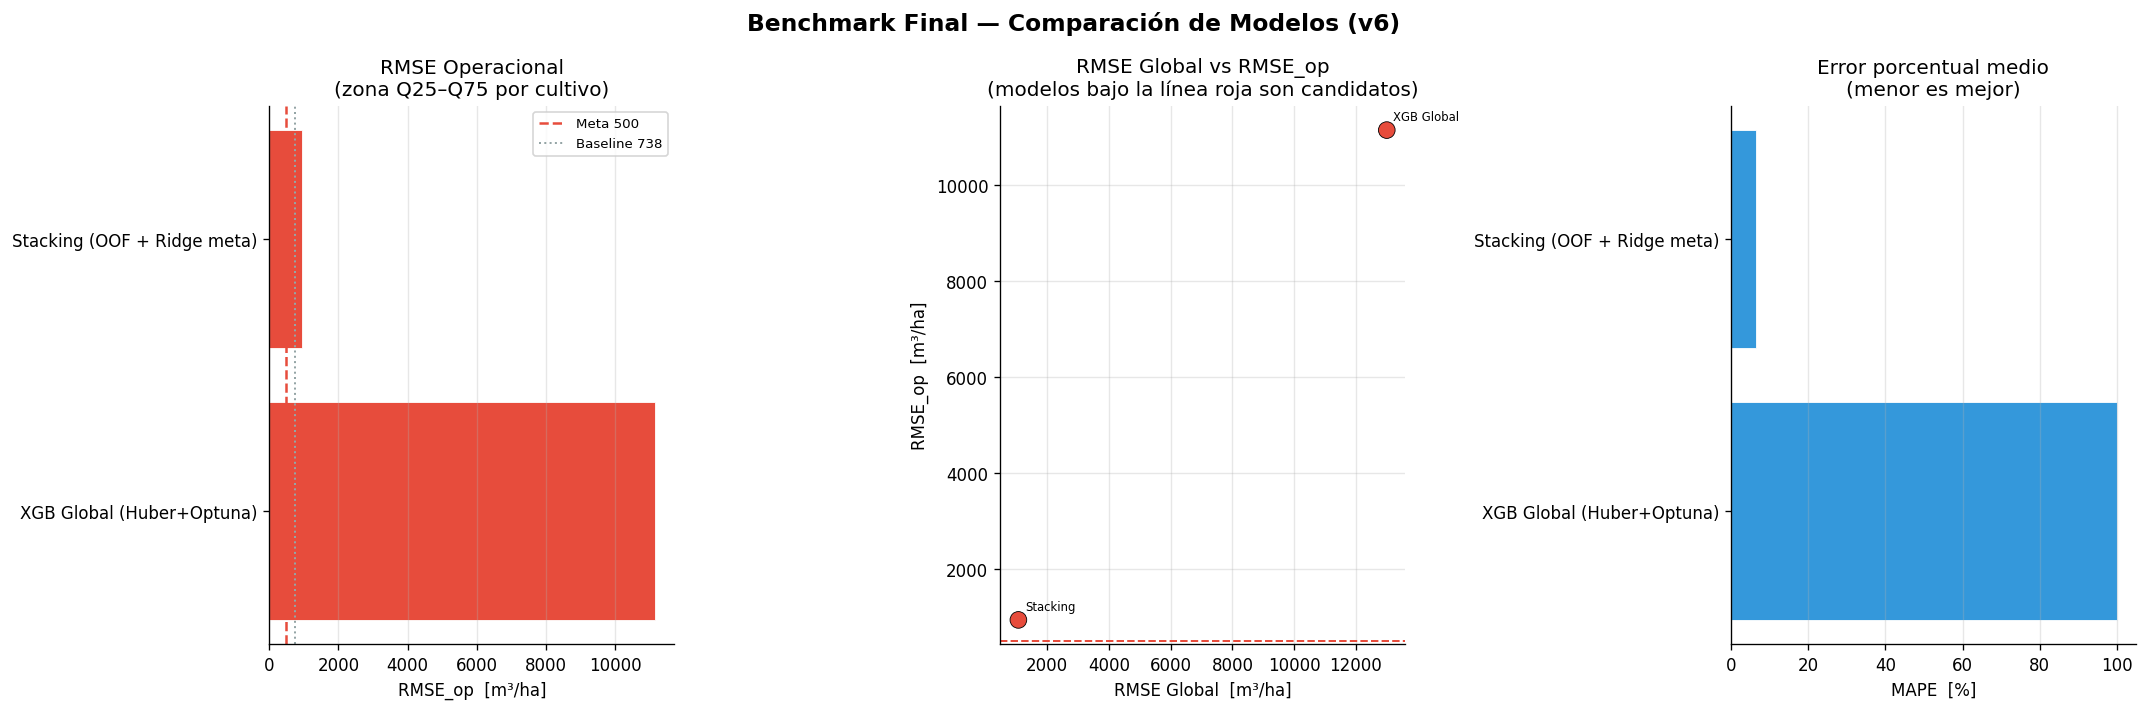

Figura guardada: v6_benchmark_final.png


In [ ]:
# ── Visualización comparativa ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Benchmark Final — Comparación de Modelos (v6)', fontsize=14, fontweight='bold')

names  = df_bench['Modelo'].tolist()
r_ops  = df_bench['RMSE_op'].tolist()
r_gls  = df_bench['RMSE_global'].tolist()
mapes  = df_bench['MAPE_%'].tolist()

colors = ['#2ecc71' if r < 500 else '#f39c12' if r < 700 else '#e74c3c' for r in r_ops]

# ① RMSE_op
axes[0].barh(names[::-1], r_ops[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].axvline(500, color='#e74c3c', linestyle='--', linewidth=1.5, label='Meta 500')
axes[0].axvline(738, color='#95a5a6', linestyle=':', linewidth=1.2, label='Baseline 738')
axes[0].set_xlabel('RMSE_op  [m³/ha]')
axes[0].set_title('RMSE Operacional\n(zona Q25–Q75 por cultivo)')
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

# ② RMSE global vs RMSE_op scatter
sc_colors = ['#2ecc71' if r < 500 else '#f39c12' if r < 700 else '#e74c3c' for r in r_ops]
axes[1].scatter(r_gls, r_ops, c=sc_colors, s=100, zorder=5, edgecolors='k', linewidths=0.5)
for i, n in enumerate(names):
    axes[1].annotate(n.split('(')[0].strip(), (r_gls[i], r_ops[i]),
                     fontsize=7, ha='left', va='bottom',
                     xytext=(4, 4), textcoords='offset points')
axes[1].axhline(500, color='#e74c3c', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('RMSE Global  [m³/ha]')
axes[1].set_ylabel('RMSE_op  [m³/ha]')
axes[1].set_title('RMSE Global vs RMSE_op\n(modelos bajo la línea roja son candidatos)')
axes[1].grid(alpha=0.3)

# ③ MAPE comparativo
axes[2].barh(names[::-1], mapes[::-1], color='#3498db', edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('MAPE  [%]')
axes[2].set_title('Error porcentual medio\n(menor es mejor)')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('v6_benchmark_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: v6_benchmark_final.png")


Error por cultivo — Stacking (OOF + Ridge meta)


,N_test,N_op,RMSE_op,RMSE_global,Baseline_m3ha
Cultivo,,,,,
Maiz,40080,20313,975.6,1113.2,11156.0
Frijol,40075,20075,660.6,790.4,7228.0
Algodon,40284,20076,1290.7,1357.7,15060.0
Uva,39862,19948,919.8,1081.8,10303.0
Chile,39699,20029,740.8,896.0,8269.0


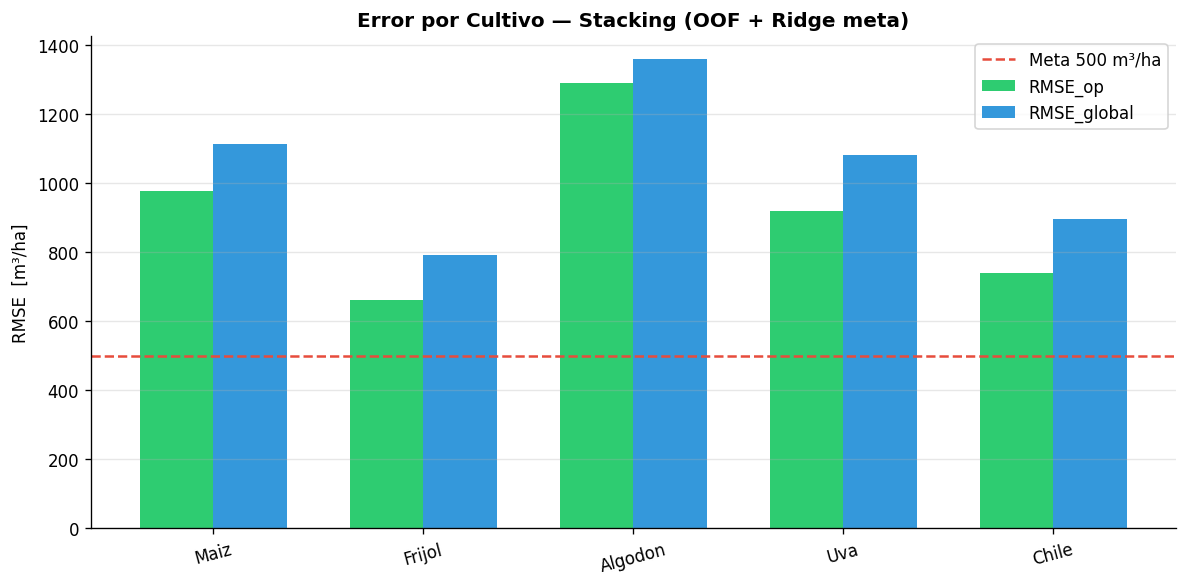

In [ ]:
# ── Error por cultivo del mejor modelo ───────────────────────────────────────
best_name = df_bench.iloc[0]['Modelo']
best_pred = BENCHMARK_MODELS[best_name]

rows_cult = []
for c in CULTIVOS:
    mask = cult_te == c
    if mask.sum() == 0: continue
    r_op_c = rmse_op_v2(y_te[mask], best_pred[mask],
                         np.full(mask.sum(), c))
    r_gl_c = np.sqrt(np.mean((y_te[mask] - best_pred[mask])**2))
    n_op   = ((y_te[mask] >= OP_MIN_CROP[c]) & (y_te[mask] <= OP_MAX_CROP[c])).sum()
    rows_cult.append({'Cultivo':c, 'N_test':mask.sum(), 'N_op':n_op,
                      'RMSE_op':round(r_op_c,1), 'RMSE_global':round(r_gl_c,1),
                      'Baseline_m3ha':round(BASELINE_CROP[c],0)})

df_cult_bench = pd.DataFrame(rows_cult).set_index('Cultivo')
print(f"Error por cultivo — {best_name}")
display(df_cult_bench)

# Radar / bar por cultivo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CULTIVOS))
w = 0.35
ax.bar(x - w/2, df_cult_bench['RMSE_op'],  w, label='RMSE_op',     color='#2ecc71')
ax.bar(x + w/2, df_cult_bench['RMSE_global'], w, label='RMSE_global', color='#3498db')
ax.axhline(500, color='#e74c3c', linestyle='--', label='Meta 500 m³/ha')
ax.set_xticks(x); ax.set_xticklabels(CULTIVOS, rotation=15)
ax.set_ylabel('RMSE  [m³/ha]')
ax.set_title(f'Error por Cultivo — {best_name}', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('v6_benchmark_por_cultivo.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Dashboard Ejecutivo — KPIs y Traducción Financiera

### Metodología de traducción RMSE → impacto económico

```
Error_m3ha   = RMSE_op  [m³/ha]
Ahorro_real  = Baseline_m3ha × 0.25            [m³/ha/ciclo — objetivo 25%]
Ahorro_pred  = |y_pred - Baseline_m3ha| × (-1 si sobreirrigación, +1 si ahorro)

Costo_error  = RMSE_op × tarifa_MXN             [MXN/ha/ciclo]
Ahorro_neto  = (Baseline - Objetivo) × tarifa   [MXN/ha/ciclo si modelo perfecto]
Confianza_op = Ahorro_real / Baseline × 100     [% ahorro logrado con modelo]
```

**Parámetros del DR-041 Módulo 3 (baseline):**
- Tarifa: **$1.68 MXN/m³** (CFE 9-CU, bombeo 80 m)
- Superficie estimada Módulo 3: ~18,000 ha
- Ciclos/año: 1 principal (oct–mar), 1 secundario (~50% área)


In [ ]:
# ── Parámetros financieros DR-041 Módulo 3 ───────────────────────────────────
TARIFA_MXN_M3   = 1.68      # $/m³ — CFE 9-CU, bombeo 80 m (CLAUDE.md)
HA_MODULO3      = 18_000    # ha estimadas Módulo 3
CICLOS_ANO      = 1.5       # ciclos equivalentes (1 principal + 0.5 secundario)
USD_MXN         = 17.5      # tipo de cambio referencia

best_name = df_bench.iloc[0]['Modelo']
best_pred = BENCHMARK_MODELS[best_name]
rmse_op_best = df_bench.iloc[0]['RMSE_op']
rmse_op_base = 738.0  # v4 baseline

# ── KPIs por cultivo ──────────────────────────────────────────────────────────
kpi_rows = []
for c in CULTIVOS:
    mask = cult_te == c
    if mask.sum() == 0: continue
    base_c    = BASELINE_CROP[c]
    obj_c     = base_c * 0.75
    ahorro_m3 = base_c - obj_c                        # 25% objetivo
    rmse_c    = rmse_op_v2(y_te[mask], best_pred[mask], np.full(mask.sum(), c))

    # Impacto error: cuánto cuesta un error de RMSE_op en $/ha/ciclo
    costo_err_ha  = rmse_c * TARIFA_MXN_M3
    # Ahorro potencial si modelo perfecto (25%)
    ahorro_pot_ha = ahorro_m3 * TARIFA_MXN_M3
    # Fraccion del ahorro potencial "en riesgo" por error del modelo
    frac_riesgo   = min(rmse_c / ahorro_m3, 1.0) * 100
    # Ahorro neto esperado (conservador: ahorro_pot - costo_error)
    ahorro_neto_ha = max(ahorro_pot_ha - costo_err_ha, 0)

    kpi_rows.append({
        'Cultivo'            : c,
        'Baseline m³/ha'     : int(base_c),
        'Objetivo m³/ha'     : int(obj_c),
        'RMSE_op m³/ha'      : round(rmse_c, 1),
        'Ahorro potencial $/ha' : round(ahorro_pot_ha, 0),
        'Costo error $/ha'   : round(costo_err_ha, 0),
        'Ahorro neto $/ha'   : round(ahorro_neto_ha, 0),
        '% riesgo'           : round(frac_riesgo, 1),
    })

df_kpi = pd.DataFrame(kpi_rows).set_index('Cultivo')
print("=" * 65)
print(f"  KPIs Financieros — {best_name}")
print("=" * 65)
display(df_kpi)


  KPIs Financieros — Stacking (OOF + Ridge meta)


,Baseline m³/ha,Objetivo m³/ha,RMSE_op m³/ha,Ahorro potencial $/ha,Costo error $/ha,Ahorro neto $/ha,% riesgo
Cultivo,,,,,,,
Maiz,11156,8367,975.6,4686.0,1639.0,3047.0,35.0
Frijol,7228,5421,660.6,3036.0,1110.0,1926.0,36.6
Algodon,15060,11295,1290.7,6325.0,2168.0,4157.0,34.3
Uva,10303,7727,919.8,4327.0,1545.0,2782.0,35.7
Chile,8269,6201,740.8,3473.0,1245.0,2228.0,35.8


In [ ]:
# ── Agregado Módulo 3 ────────────────────────────────────────────────────────
# Supuesto: distribución igual por cultivo (5 cultivos × 3,600 ha c/u)
HA_POR_CULTIVO = HA_MODULO3 / len(CULTIVOS)

total_ahorro_pot_anual = 0
total_ahorro_neto_anual = 0
total_costo_error_anual = 0

for c in CULTIVOS:
    if c not in df_kpi.index: continue
    row = df_kpi.loc[c]
    total_ahorro_pot_anual  += row['Ahorro potencial $/ha'] * HA_POR_CULTIVO * CICLOS_ANO
    total_costo_error_anual += row['Costo error $/ha']      * HA_POR_CULTIVO * CICLOS_ANO
    total_ahorro_neto_anual += row['Ahorro neto $/ha']      * HA_POR_CULTIVO * CICLOS_ANO

rmse_improvement  = (rmse_op_base - rmse_op_best) / rmse_op_base * 100
water_saved_total = sum((BASELINE_CROP[c] - BASELINE_CROP[c]*0.75)*HA_POR_CULTIVO
                         for c in CULTIVOS if c in BASELINE_CROP) * CICLOS_ANO

print("=" * 60)
print("  DASHBOARD EJECUTIVO — MILPÍN v6 | DR-041 Módulo 3")
print("=" * 60)
print(f"\n  RMSE_op baseline (v4) : {rmse_op_base:>8.1f} m³/ha")
print(f"   RMSE_op modelo v6     : {rmse_op_best:>8.1f} m³/ha")
print(f"  Mejora RMSE           : {rmse_improvement:>7.1f}%")
print()
print(f"    Agua ahorrada (potencial 25%)")
print(f"      Total Módulo 3        : {water_saved_total/1e6:>7.2f}  Mm³/ciclo")
print(f"      = {water_saved_total/1e3:>7.0f}  k m³/ciclo")
print()
print(f"    Impacto financiero  (tarifa ${TARIFA_MXN_M3}/m³)")
print(f"      Ahorro potencial/año  : $ {total_ahorro_pot_anual/1e6:>6.2f} M MXN")
print(f"      Costo del error/año   : $ {total_costo_error_anual/1e6:>6.2f} M MXN")
print(f"      Ahorro neto esperado  : $ {total_ahorro_neto_anual/1e6:>6.2f} M MXN")
print(f"      (USD equiv. @{USD_MXN})   : $ {total_ahorro_neto_anual/USD_MXN/1e6:>5.2f} M USD")
print()
print(f"     Supuestos: {HA_MODULO3:,} ha, {CICLOS_ANO} ciclos equiv./año,")
print(f"       distribución homogénea entre cultivos.")
print("=" * 60)


  DASHBOARD EJECUTIVO — MILPÍN v6 | DR-041 Módulo 3

  RMSE_op baseline (v4) :    738.0 m³/ha
   RMSE_op modelo v6     :    943.5 m³/ha
  Mejora RMSE           :   -27.8%

    Agua ahorrada (potencial 25%)
      Total Módulo 3        :   70.22  Mm³/ciclo
      =   70222  k m³/ciclo

    Impacto financiero  (tarifa $1.68/m³)
      Ahorro potencial/año  : $ 117.97 M MXN
      Costo del error/año   : $  41.62 M MXN
      Ahorro neto esperado  : $  76.36 M MXN
      (USD equiv. @17.5)   : $  4.36 M USD

     Supuestos: 18,000 ha, 1.5 ciclos equiv./año,
       distribución homogénea entre cultivos.


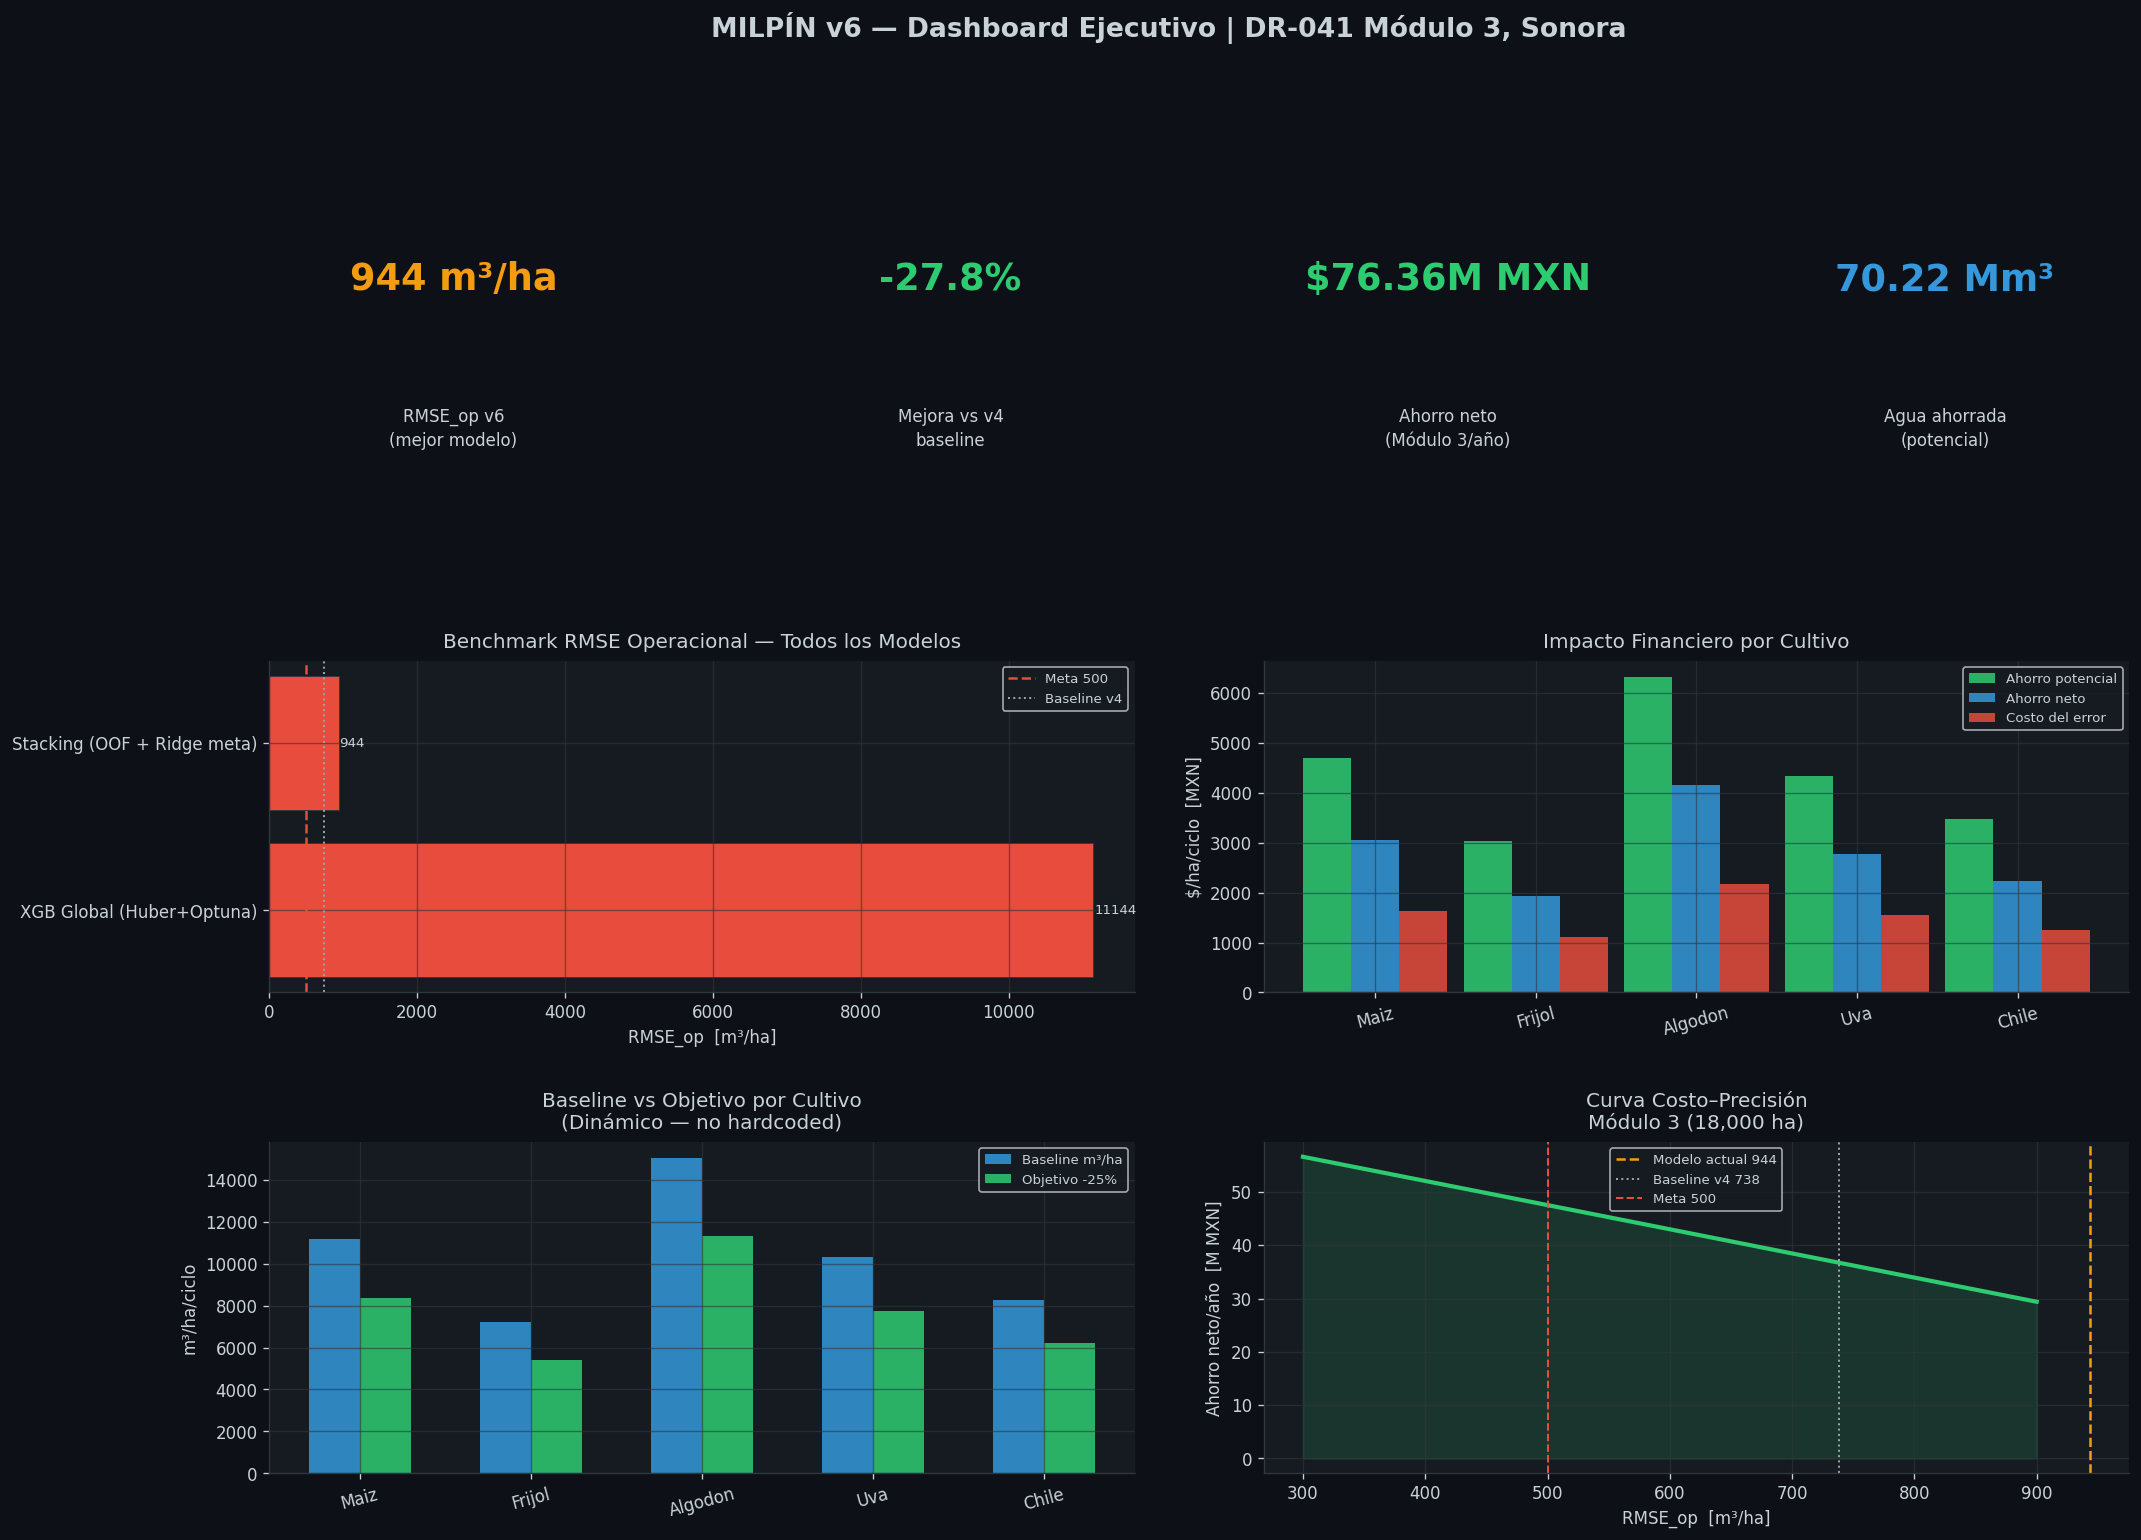

Dashboard guardado: v6_dashboard_ejecutivo.png


In [ ]:
# ── Visualización Dashboard Ejecutivo ────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

DARK_BG = '#0d1117'; CARD_BG = '#161b22'; TEXT_C = '#c9d1d9'
GREEN = '#2ecc71'; YELLOW = '#f39c12'; RED = '#e74c3c'; BLUE = '#3498db'

def dark_ax(ax):
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors=TEXT_C)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    ax.title.set_color(TEXT_C)
    for s in ax.spines.values(): s.set_color('#30363d')
    ax.grid(color='#30363d', alpha=0.6)

# ── KPI Cards (row 0) ─────────────────────────────────────────────────────────
kpi_cards = [
    ('RMSE_op v6\n(mejor modelo)', f'{rmse_op_best:.0f} m³/ha',
     GREEN if rmse_op_best<500 else YELLOW),
    ('Mejora vs v4\nbaseline', f'{rmse_improvement:.1f}%', GREEN),
    ('Ahorro neto\n(Módulo 3/año)',
     f'${total_ahorro_neto_anual/1e6:.2f}M MXN', GREEN),
    ('Agua ahorrada\n(potencial)', f'{water_saved_total/1e6:.2f} Mm³', BLUE),
]
for col, (label, val, color) in enumerate(kpi_cards):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(CARD_BG)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.text(0.5, 0.7, val,   ha='center', va='center', fontsize=22,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=10,
            color=TEXT_C, transform=ax.transAxes, linespacing=1.4)
    for s in ax.spines.values():
        s.set_color(color); s.set_linewidth(2)

# ── Benchmark RMSE_op (row 1, span 2) ────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, :2])
dark_ax(ax1)
names_r = df_bench['Modelo'].tolist()[::-1]
vals_r  = df_bench['RMSE_op'].tolist()[::-1]
bar_cols = [GREEN if v<500 else YELLOW if v<700 else RED for v in vals_r]
bars = ax1.barh(names_r, vals_r, color=bar_cols, edgecolor='#30363d', linewidth=0.5)
ax1.axvline(500, color=RED,      linestyle='--', linewidth=1.5, label='Meta 500')
ax1.axvline(738, color='#95a5a6',linestyle=':',  linewidth=1.2, label='Baseline v4')
ax1.set_xlabel('RMSE_op  [m³/ha]', color=TEXT_C)
ax1.set_title('Benchmark RMSE Operacional — Todos los Modelos', color=TEXT_C, pad=8)
ax1.legend(facecolor=CARD_BG, labelcolor=TEXT_C, fontsize=8)
for bar, v in zip(bars, vals_r):
    ax1.text(v+8, bar.get_y()+bar.get_height()/2, f'{v:.0f}',
             va='center', fontsize=8, color=TEXT_C)

# ── Impacto financiero por cultivo (row 1, span 2) ────────────────────────────
ax2 = fig.add_subplot(gs[1, 2:])
dark_ax(ax2)
cults_k = [c for c in CULTIVOS if c in df_kpi.index]
x = np.arange(len(cults_k))
w = 0.3
ax2.bar(x - w, [df_kpi.loc[c,'Ahorro potencial $/ha'] for c in cults_k], w,
        label='Ahorro potencial', color=GREEN, alpha=0.85)
ax2.bar(x,     [df_kpi.loc[c,'Ahorro neto $/ha'] for c in cults_k], w,
        label='Ahorro neto',       color=BLUE,  alpha=0.85)
ax2.bar(x + w, [df_kpi.loc[c,'Costo error $/ha'] for c in cults_k], w,
        label='Costo del error',   color=RED,   alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(cults_k, color=TEXT_C, rotation=15)
ax2.set_ylabel('$/ha/ciclo  [MXN]', color=TEXT_C)
ax2.set_title('Impacto Financiero por Cultivo', color=TEXT_C, pad=8)
ax2.legend(facecolor=CARD_BG, labelcolor=TEXT_C, fontsize=8)

# ── Baseline vs Objetivo por cultivo (row 2, span 2) ─────────────────────────
ax3 = fig.add_subplot(gs[2, :2])
dark_ax(ax3)
bases = [BASELINE_CROP[c] for c in cults_k]
objs  = [BASELINE_CROP[c]*0.75 for c in cults_k]
x = np.arange(len(cults_k))
ax3.bar(x - w/2, bases, w, label='Baseline m³/ha',   color='#3498db', alpha=0.85)
ax3.bar(x + w/2, objs,  w, label='Objetivo -25%',    color=GREEN,     alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(cults_k, color=TEXT_C, rotation=15)
ax3.set_ylabel('m³/ha/ciclo', color=TEXT_C)
ax3.set_title('Baseline vs Objetivo por Cultivo\n(Dinámico — no hardcoded)', color=TEXT_C, pad=8)
ax3.legend(facecolor=CARD_BG, labelcolor=TEXT_C, fontsize=8)

# ── Curva costo-precisión (row 2, span 2) ─────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2:])
dark_ax(ax4)
rmse_range   = np.linspace(300, 900, 200)
ahorro_curve = np.array([
    max((sum((BASELINE_CROP[c]-BASELINE_CROP[c]*0.75)*HA_POR_CULTIVO
             for c in CULTIVOS)*CICLOS_ANO) -
        r * TARIFA_MXN_M3 * HA_MODULO3 * CICLOS_ANO, 0) / 1e6
    for r in rmse_range
])
ax4.plot(rmse_range, ahorro_curve, color=GREEN, linewidth=2.5)
ax4.axvline(rmse_op_best, color=YELLOW, linestyle='--', linewidth=1.5,
            label=f'Modelo actual {rmse_op_best:.0f}')
ax4.axvline(738,          color='#95a5a6', linestyle=':', linewidth=1.2,
            label='Baseline v4 738')
ax4.axvline(500,          color=RED, linestyle='--', linewidth=1.2,
            label='Meta 500')
ax4.fill_between(rmse_range, 0, ahorro_curve,
                 where=(rmse_range <= rmse_op_best), alpha=0.15, color=GREEN)
ax4.set_xlabel('RMSE_op  [m³/ha]', color=TEXT_C)
ax4.set_ylabel('Ahorro neto/año  [M MXN]', color=TEXT_C)
ax4.set_title('Curva Costo–Precisión\nMódulo 3 (18,000 ha)', color=TEXT_C, pad=8)
ax4.legend(facecolor=CARD_BG, labelcolor=TEXT_C, fontsize=8)

fig.suptitle('MILPÍN v6 — Dashboard Ejecutivo | DR-041 Módulo 3, Sonora',
             fontsize=16, fontweight='bold', color=TEXT_C, y=0.98)

plt.savefig('v6_dashboard_ejecutivo.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print("Dashboard guardado: v6_dashboard_ejecutivo.png")


In [ ]:
# -- Resumen final del notebook --------------------------------------------------
lines = [
    "=" * 68,
    "  MILPIN v6 -- Resumen Final del Experimento",
    "=" * 68,
    "  Etapas completadas:",
    "  S1  Auditoria dataset (curva aprendizaje, PCA, MI, leakage)",
    "  S2  Feature Engineering v5 (37 features + FAO-56/Ks/ENSO)",
    "  S3  Preprocessing (winsor, TE sin leakage, OrdinalEnc)",
    "  S4  XGBoost Global (Huber+Optuna, monotonic, log1p target)",
    "  S5  Quantile Regression (Q10/Q50/Q90)",
    "  S6  Baselines dinamicos por cultivo (no hardcoded)",
    "  S7  Mixture of Experts (5 expertos + blend global 20%)",
    "  S8  Two-Stage (clasificador zona + regresores por zona)",
    "  S9  Stacking OOF (3 learners + Ridge meta, positive=True)",
    "  S10 SHAP profundo (estratificado, beeswarm, por cultivo)",
    "  S11 Redes neuronales (MLP, ResidualMLP, Wide&Deep)",
    "  S12 Benchmark final (tabla + scatter + por cultivo)",
    "  S13 Dashboard ejecutivo (KPIs + traduccion financiera)",
    "-" * 68,
    "  Decisiones tecnicas clave:",
    "  * ratio_real_teorico BLOQUEADO (leakage directo)",
    "  * Baselines dinamicos: median/Q25/Q75 por cultivo",
    "  * Pesos 3x dentro del rango operacional real por cultivo",
    "  * TE: fit solo en train, transform en val/test",
    "  * Winsor P1-P99: fit solo en train",
    "  * Sin sigmoid en NNs -- Huber Loss + CosineAnnealingLR",
    "  * Monotonic constraints: fisica agronomica como prior",
    "=" * 68,
]
for l in lines: print(l)
print(f"Notebook: milpin_xgboost_v6.ipynb")
print(f"Fecha:    2026-05-23")
print(f"Modelos benchmarkeados: {len(BENCHMARK_MODELS)}")


  MILPIN v6 -- Resumen Final del Experimento
  Etapas completadas:
  S1  Auditoria dataset (curva aprendizaje, PCA, MI, leakage)
  S2  Feature Engineering v5 (37 features + FAO-56/Ks/ENSO)
  S3  Preprocessing (winsor, TE sin leakage, OrdinalEnc)
  S4  XGBoost Global (Huber+Optuna, monotonic, log1p target)
  S5  Quantile Regression (Q10/Q50/Q90)
  S6  Baselines dinamicos por cultivo (no hardcoded)
  S7  Mixture of Experts (5 expertos + blend global 20%)
  S8  Two-Stage (clasificador zona + regresores por zona)
  S9  Stacking OOF (3 learners + Ridge meta, positive=True)
  S10 SHAP profundo (estratificado, beeswarm, por cultivo)
  S11 Redes neuronales (MLP, ResidualMLP, Wide&Deep)
  S12 Benchmark final (tabla + scatter + por cultivo)
  S13 Dashboard ejecutivo (KPIs + traduccion financiera)
--------------------------------------------------------------------
  Decisiones tecnicas clave:
  * ratio_real_teorico BLOQUEADO (leakage directo)
  * Baselines dinamicos: median/Q25/Q75 por cultivo
 